# TP 3

## Objectifs

1.  Travaux sur les [modèles de régression linéaire](http://scikit-learn.org/stable/modules/linear_model.html) (simple et polynomiale)
2.  Explorer les [algorithmes de classification](http://scikit-learn.org/stable/modules/svm.html) (Perceptron, SVM, MLPClassifier)
3.  Comprendre les [arbres de décision](https://en.wikipedia.org/wiki/Decision_tree) et les [forêts aléatoires](https://en.wikipedia.org/wiki/Random_forest)
4.  Découvrir l'apprentissage en ligne/incrémental

## Prérequis

-   Avoir terminé [TP 0](../TP0/tp0.ipynb), [TP 1](../TP1/tp1.ipynb), et [TP 2](../TP2/tp2.ipynb)
-   Compréhension de base des concepts d'apprentissage automatique

## Vue d'ensemble des exercices

| Exercice | Difficulté | Thèmes |
|----------|------------|--------|
| Exercice 1 | ★ | Régression linéaire, caractéristiques polynomiales |
| Exercice 2 | ★★ | Classification (Perceptron, SVM, MLP), MNIST |
| Exercice 3 | ★★ | Arbres de décision, forêts aléatoires, importance des caractéristiques |
| Exercice 4 | ★★ | Apprentissage en ligne/incrémental |

## Concepts clés

- **Régression** : Prédire des valeurs continues (ex. population, prix)
- **Classification** : Prédire des catégories/étiquettes (ex. reconnaissance de chiffres)
- **Apprentissage supervisé** : Apprendre à partir de données d'entraînement étiquetées

## Exercice 1 \[★\]

Nous allons maintenant travailler avec la **régression linéaire** (voir [ici](http://scikit-learn.org/stable/modules/linear_model.html#ordinary-least-squares)).

Voyons quelques programmes simples. Dans l'exemple suivant, où nous avons quelques exemples de données pour l'équation : *y = x*. Nous allons d'abord entraîner notre modèle de régression linéaire avec un très petit sous-ensemble et tester s'il est capable de prédire les valeurs *y-* pour de nouvelles valeurs *x-*.

In [42]:
import numpy as np
import matplotlib.pyplot as plot
from sklearn.linear_model import LinearRegression

numarray = np.array([[0, 0], [1, 1], [2, 2], [3, 3], [4, 4], [5, 5]])

lr = LinearRegression()
lr.fit(numarray[:, 0].reshape(-1, 1), numarray[:, 1].reshape(-1, 1))

# printing coefficients
print(lr.intercept_, lr.coef_)

x_predict = np.array([6, 7, 8, 9, 10])

y_predict = lr.predict(x_predict.reshape(-1, 1))
y_predict

[0.] [[1.]]


array([[ 6.],
       [ 7.],
       [ 8.],
       [ 9.],
       [10.]])

Nous avons obtenu les valeurs de l'intercept et des coefficients. 

$ y = ax + b, a = 1, b = 0$

Ensuite, nous avons quelques exemples de données pour l'équation : *y = x + 1*. Nous allons entraîner notre modèle de régression linéaire à tester s'il est capable de prédire les valeurs *y-* pour les nouvelles valeurs *x-*.

In [44]:
import numpy as np
import matplotlib.pyplot as plot
from sklearn.linear_model import LinearRegression

numarray = np.array([[0, 1], [1, 2], [2, 3], [3, 4], [4, 5], [5, 6]])

lr = LinearRegression()
lr.fit(numarray[:, 0].reshape(-1, 1), numarray[:, 1].reshape(-1, 1))

# printing coefficients
print(lr.intercept_, lr.coef_)

x_predict = np.array([6, 7, 8, 9, 10])

y_predict = lr.predict(x_predict.reshape(-1, 1))
y_predict

[1.] [[1.]]


array([[ 7.],
       [ 8.],
       [ 9.],
       [10.],
       [11.]])

Nous avons obtenu les valeurs de l'intercept et des coefficients. 

$ y = ax + b, a = 1, b = 1$


In [3]:
import numpy as np
import matplotlib.pyplot as plot
from sklearn.linear_model import LinearRegression

numarray = np.array([[0, 2], [1, 3], [2, 4], [3, 5], [4, 6], [5, 7]])

lr = LinearRegression()
lr.fit(numarray[:, 0].reshape(-1, 1), numarray[:, 1].reshape(-1, 1))

# printing coefficients
print(lr.intercept_, lr.coef_)

x_predict = np.array([6, 7, 8, 9, 10])

y_predict = lr.predict(x_predict.reshape(-1, 1))
y_predict

[2.] [[1.]]


array([[ 8.],
       [ 9.],
       [10.],
       [11.],
       [12.]])

$ y = ax + b, a = 1, b = 2$


Maintenant, nous voulons prédire $y$ avec des vecteurs d'entrée de longueur 2. 

In [4]:
numarray1 = np.array([[0, 1], [1, 2], [2, 3], [3, 1], [4, 2], [5, 3]])
numarray2 = np.array([[6], [11], [16], [12], [17], [22]])

y = np.dot(numarray1, [2, 3]) + 3
y

array([ 6, 11, 16, 12, 17, 22])

[3.] [[2. 3.]]


array([[15.],
       [20.],
       [22.],
       [21.],
       [23.]])

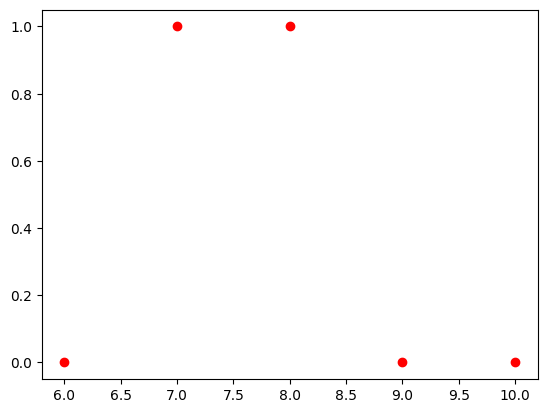

In [ ]:
import numpy as np
import matplotlib.pyplot as plot
from sklearn.linear_model import LinearRegression

y = numarray2

lr = LinearRegression()
lr.fit(numarray1, numarray2.reshape(-1, 1))

# printing coefficients
print(lr.intercept_, lr.coef_)

x_predict = np.array([[6, 0], [7, 1], [8, 1], [9, 0], [10, 0]])

y_predict = lr.predict(x_predict)
y_predict

$ y = ax + b, a = [2, 3],  b = [3]$


Mais, et si nous essayions le modèle de régression linéaire pour l'équation : **y = x²** ?

Qu'avez-vous observé avec le code suivant ? A-t-il prédit les valeurs *y-* correctement ?

**Comportement attendu** : La régression linéaire essaie d'ajuster une droite, mais la relation y = x² est courbe (quadratique). Les prédictions seront inexactes car un modèle linéaire ne peut pas capturer les motifs non linéaires.

⚠️ Pour le modèle de régression linéaire, nous avons obtenu les valeurs de l'intercept et des coefficients.
Avec l'équation y = x² c'est un peu particulier car la régression linéaire essaie d'ajuster une droite, mais la relation y = x² est courbe (quadratique). Les prédictions seront inexactes car un modèle linéaire ne peut pas capturer les motifs non linéaires. ⚠️

In [6]:
import numpy as np
import matplotlib.pyplot as plot
from sklearn.linear_model import LinearRegression

numarray = np.array([[0, 0], [1, 1], [2, 4], [3, 9], [4, 16], [5, 25]])

lr = LinearRegression()
lr.fit(numarray[:, 0].reshape(-1, 1), numarray[:, 1].reshape(-1, 1))

# printing coefficients
print(lr.intercept_, lr.coef_)

x_predict = np.array([6, 7, 8, 9, 10])

y_predict = lr.predict(x_predict.reshape(-1, 1))
y_predict

[-3.33333333] [[5.]]


array([[26.66666667],
       [31.66666667],
       [36.66666667],
       [41.66666667],
       [46.66666667]])

### Caractéristiques polynomiales

Pour capturer les relations non linéaires, nous pouvons utiliser les **Caractéristiques polynomiales** (Polynomial Features). Cela transforme nos caractéristiques d'entrée en ajoutant des termes polynomiaux.

Par exemple, avec `degree=2` :
- Entrée : [x]
- Sortie : [1, x, x²]

Cela permet à un modèle linéaire d'ajuster des courbes ! Essayez de changer la valeur de `degree` dans le code ci-dessous.

**Idée clé** : Nous utilisons toujours LinearRegression, mais sur des caractéristiques transformées qui incluent des termes polynomiaux.

In [7]:
import numpy as np
import matplotlib.pyplot as plot
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

numarray = np.array([[0, 0], [1, 1], [2, 4], [3, 9], [4, 16], [5, 25]])

# using polynomial features
pf = PolynomialFeatures(degree=2)
x_poly = pf.fit_transform(numarray[:, 0].reshape(-1, 1))
lr = LinearRegression()
lr.fit(x_poly, numarray[:, 1].reshape(-1, 1))

# printing coefficients
print(pf.get_feature_names_out())
print(lr.intercept_, lr.coef_)

x_predict = np.array([6, 7, 8, 9, 10])

y_predict = lr.predict(pf.fit_transform(x_predict.reshape(-1, 1)))
y_predict

['1' 'x0' 'x0^2']
[0.] [[ 0.00000000e+00 -1.76605997e-15  1.00000000e+00]]


array([[ 36.],
       [ 49.],
       [ 64.],
       [ 81.],
       [100.]])

$ y = 1.a + b.x0 + c.x0^2 + intercept $

$ a =0, b = -1.55431223e-15, c = 1, intercept = 1.77635684e-15 $

In [8]:
import numpy as np
import matplotlib.pyplot as plot
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

numarray = np.array([[0, 1], [1, 3], [2, 7], [3, 13], [4, 21], [5, 31]])

# using polynomial features
pf = PolynomialFeatures(degree=2)
x_poly = pf.fit_transform(numarray[:, 0].reshape(-1, 1))
lr = LinearRegression()
lr.fit(x_poly, numarray[:, 1].reshape(-1, 1))

# printing coefficients
print(pf.get_feature_names_out())
print(lr.intercept_, lr.coef_)

x_predict = np.array([6, 7, 8, 9, 10])

y_predict = lr.predict(pf.fit_transform(x_predict.reshape(-1, 1)))

# features
y_predict

['1' 'x0' 'x0^2']
[1.] [[0. 1. 1.]]


array([[ 43.],
       [ 57.],
       [ 73.],
       [ 91.],
       [111.]])

$ y = 1.a + b.x0 + c.x0^2 + intercept $

$ a =0, b = 1, c = 1, intercept = 1 $

Essayons maintenant avec une équation polynomiale du troisième ordre (équation cubique).

In [9]:
import numpy as np
import matplotlib.pyplot as plot
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

numarray = np.array([[0, 0], [1, 1], [2, 8], [3, 27], [4, 64], [5, 125]])

# using polynomial features
pf = PolynomialFeatures(degree=3)
x_poly = pf.fit_transform(numarray[:, 0].reshape(-1, 1))
lr = LinearRegression()
lr.fit(x_poly, numarray[:, 1].reshape(-1, 1))

# printing coefficients
print(pf.get_feature_names_out())
print(lr.intercept_, lr.coef_)

x_predict = np.array([6, 7, 8, 9, 10])

y_predict = lr.predict(pf.fit_transform(x_predict.reshape(-1, 1)))
y_predict

['1' 'x0' 'x0^2' 'x0^3']
[0.] [[ 0.00000000e+00  2.88263196e-15 -1.08754517e-15  1.00000000e+00]]


array([[ 216.],
       [ 343.],
       [ 512.],
       [ 729.],
       [1000.]])

$ y = 1.a + b.x0 + c.x0^2 + d.x0^3 + intercept $

$ a =0, b = 1.44328993e-15, c = 3.63598041e-15 , d=1, intercept = 2.13162821e-14 $

Nous utiliserons le fichier [population.csv](../../data/population.csv)
Nous allons d'abord tracer cette population pluriannuelle.

<Axes: xlabel='year', ylabel='population'>

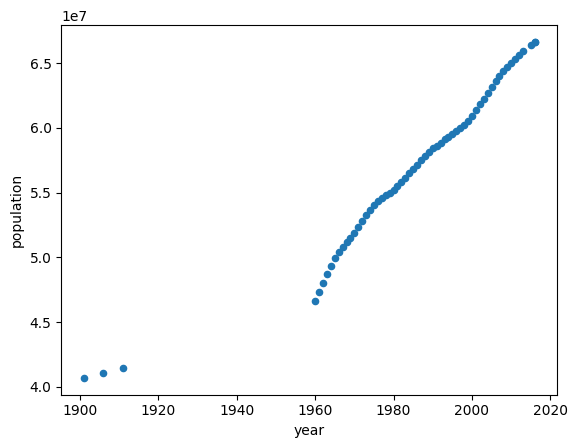

In [10]:
import numpy as np
import matplotlib.pyplot as plot
import pandas as pd

dataset = np.loadtxt(
    "../../data/population.csv",
    dtype={"names": ("year", "population"), "formats": ("i4", "i")},
    skiprows=1,
    delimiter=",",
    encoding="UTF-8",
)

df = pd.DataFrame(dataset)
df.plot(x="year", y="population", kind="scatter")

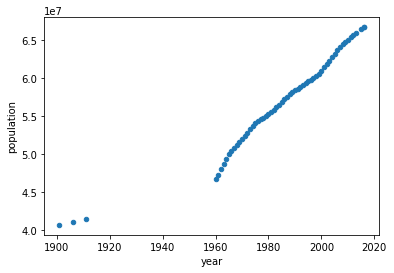

Nous nous concentrerons sur les données à partir de 1960 (pourquoi ?). Notre objectif est d'utiliser
des techniques de régression pour prédire la population. Mais nous ne savons pas comment vérifier. Donc, avec les données disponibles, nous créons deux catégories : les données de formation et les données de test.

Nous continuons maintenant avec les données de population (de TP1 et TP2), que nous divisons en deux : les données d'entraînement et les données de test. Nous allons tracer les valeurs réelles de la population et les valeurs prédites.


[-5.86674085e+08] [[324065.22138837]]


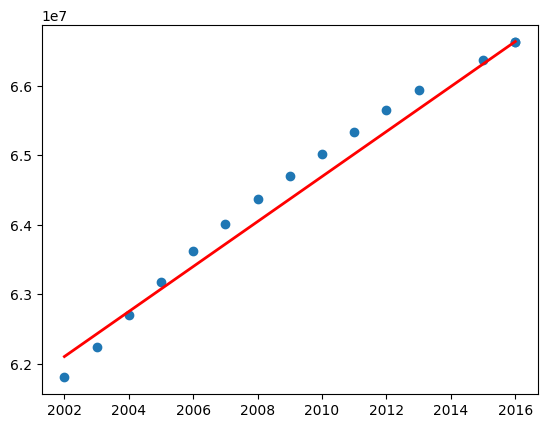

In [11]:
import numpy as np
import matplotlib.pyplot as plot
import pandas as pd
from sklearn.linear_model import LinearRegression

dataset = np.loadtxt(
    "../../data/population.csv",
    dtype={"names": ("year", "population"), "formats": ("i4", "i")},
    skiprows=1,
    delimiter=",",
    encoding="UTF-8",
)

df = pd.DataFrame(dataset[4:])

# training data
x_train = df["year"][:40].values.reshape(-1, 1)
y_train = df["population"][:40].values.reshape(-1, 1)

# training
lr = LinearRegression()
lr.fit(x_train, y_train)

# printing coefficients
print(lr.intercept_, lr.coef_)

# prediction
x_predict = x_train = df["year"][41:].values.reshape(-1, 1)
y_actual = df["population"][41:].values.reshape(-1, 1)
y_predict = lr.predict(x_predict)

plot.scatter(x_predict, y_actual)
plot.plot(x_predict, y_predict, color="red", linewidth=2)
plot.show()

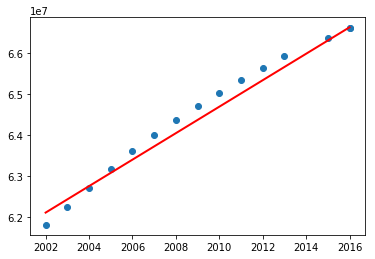

Testez maintenant le programme ci-dessus en incluant les données antérieures à 1960. Qu'avez-vous remarqué ? Vous avez peut-être le graphique suivant.

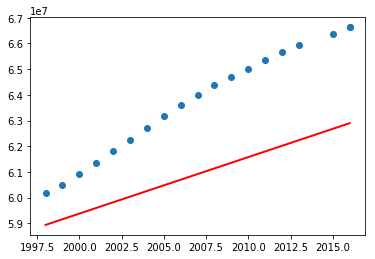

Quelles sont vos observations ? Le programme ci-dessus, qui utilise la régression linéaire, convient donc parfaitement à un sous-ensemble de données. Essayons maintenant avec des **caractéristiques polynomiales** (PolynomialFeatures) de degré 2 (voir [Polynomial Regression: Extending linear models](http://scikit-learn.org/stable/modules/linear_model.html#polynomial-regression-extending-linear-models-with-basis-functions)).



[-4.30491266e+09] [[ 0.00000000e+00  4.06776344e+06 -9.42279929e+02]]


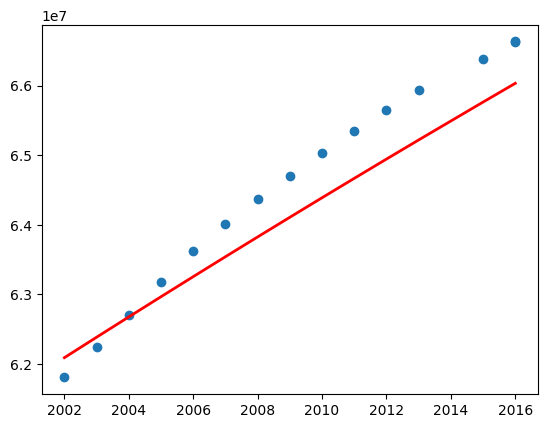

In [12]:
import numpy as np
import matplotlib.pyplot as plot
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

dataset = np.loadtxt(
    "../../data/population.csv",
    dtype={"names": ("year", "population"), "formats": ("i4", "i")},
    skiprows=1,
    delimiter=",",
    encoding="UTF-8",
)

df = pd.DataFrame(dataset[4:])

# training data

x_train = df["year"][:50].values.reshape(-1, 1)
y_train = df["population"][:50].values.reshape(-1, 1)

pf = PolynomialFeatures(degree=2)
x_poly = pf.fit_transform(x_train)

# training
lr = LinearRegression()
lr.fit(x_poly, y_train)

# printing coefficients
print(lr.intercept_, lr.coef_)

# prediction
x_predict = x_train = df["year"][41:].values.reshape(-1, 1)
y_actual = df["population"][41:].values.reshape(-1, 1)
y_predict = lr.predict(pf.fit_transform(x_predict))

plot.scatter(x_predict, y_actual)
plot.plot(x_predict, y_predict, color="red", linewidth=2)
plot.show()

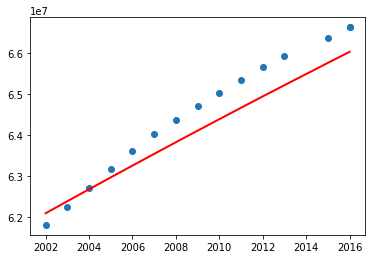

Avant de passer à la conclusion, examinons l'ensemble des données et voyons.

[9.70353598e+10] [[ 0.00000000e+00 -1.15416461e+02 -1.50743848e+05  1.02205549e+02
  -1.94777035e-02]]


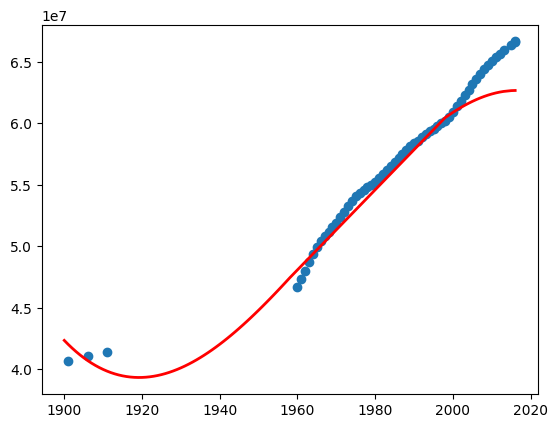

In [3]:
import numpy as np
import matplotlib.pyplot as plot
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

dataset = np.loadtxt(
    "../../data/population.csv",
    dtype={"names": ("year", "population"), "formats": ("i4", "i")},
    skiprows=1,
    delimiter=",",
    encoding="UTF-8",
)

df = pd.DataFrame(dataset)

# training data

x_train = df["year"][:40].values.reshape(-1, 1)
y_train = df["population"][:40].values.reshape(-1, 1)

pf = PolynomialFeatures(degree=4)
x_poly = pf.fit_transform(x_train)

# training
lr = LinearRegression()
lr.fit(x_poly, y_train)

# printing coefficients
print(lr.intercept_, lr.coef_)

# prediction
x_predict = x_train = df["year"][41:].values.reshape(-1, 1)

# Let's add some more years
x_predict = np.append(range(1900, 1959), x_predict)
x_predict = x_predict.reshape(-1, 1)

y_actual = df["population"][41:].values.reshape(-1, 1)
y_predict = lr.predict(pf.fit_transform(x_predict))

plot.scatter(df["year"], df["population"])
plot.plot(x_predict, y_predict, color="red", linewidth=2)
plot.show()

![](attachment:../../images/allpopulationpolynomialregression.png)

**Question 1 : Exploration du degré polynomial**

1. Peut-on utiliser ce programme pour prédire les données manquantes (surtout en l'absence d'autres sources d'information externes) ?

`réponse:` Oui, on peut utiliser ce programme pour prédire les données manquantes, mais la précision de ces prédictions dépendra fortement du degré du polynôme utilisé. Un degré trop bas (underfitting) peut ne pas capturer la complexité des données, tandis qu'un degré trop élevé (overfitting) peut capturer le bruit plutôt que la tendance générale, ce qui peut conduire à des prédictions inexactes. Il est donc crucial de choisir un degré approprié pour obtenir des prédictions fiables.

2. Essayez le programme ci-dessus avec différents degrés (1, 2, 3, 4, 5). Que se passe-t-il avec :
   - Des degrés très bas (sous-ajustement) ?
   - Des degrés très élevés (sur-ajustement) ?

`réponse:` Avec des degrés très bas (sous-ajustement), le modèle ne capture pas la complexité des données, ce qui conduit à des prédictions inexactes et à une mauvaise performance sur les données de test. Avec des degrés très élevés (sur-ajustement), le modèle capture non seulement la tendance générale mais aussi le bruit dans les données d'entraînement, ce qui peut également conduire à des prédictions inexactes sur les données de test. Il est important de trouver un équilibre pour éviter à la fois le sous-ajustement et le sur-ajustement.


3. **Expérience** : Divisez les données en entraînement (les 40 premières années) et test (les années restantes). Calculez l'erreur quadratique moyenne (MSE) pour différents degrés polynomiaux. Quel degré donne les meilleures prédictions sur les données de test ?

**Indice** : Utilisez `from sklearn.metrics import mean_squared_error`

`réponse:` En calculant l'erreur quadratique moyenne (MSE) pour différents degrés polynomiaux, on peut déterminer quel degré offre les meilleures prédictions sur les données de test. En général, on s'attend à ce que le MSE diminue à mesure que le degré augmente jusqu'à un certain point, après quoi il peut commencer à augmenter en raison du sur-ajustement. Le degré qui donne le MSE le plus bas sur les données de test est celui qui offre les meilleures prédictions.

X_train: [1901 1906 1911 1960 1961 1962 1963 1964 1965 1966 1967 1968 1969 1970
 1971 1972 1973 1974 1975 1976 1977 1978 1979 1980 1981 1982 1983 1984
 1985 1986 1987 1988 1989 1990 1991 1992 1993 1994 1995 1996]
Y_train: [40681000 41067000 41415000 46647521 47293811 47990159 48697015 49361165
 49945471 50430631 50829214 51175036 51518731 51895793 52320049 52776806
 53239101 53666947 54033095 54328016 54565943 54772084 54982879 55224670
 55505282 55816654 56149874 56489874 56825158 57155165 57482783 57803824
 58113622 58409202 58557072 58849212 59105073 59325793 59540711 59752020]
X_test: [1997 1998 1999 2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010
 2011 2012 2013 2015 2016 2016]
Y_test: [59963792 60185178 60495470 60911057 61355725 61803229 62242474 62702121
 63176246 63617975 64012572 64371099 64702921 65023142 65343588 65649570
 65939866 66380602 66632870 66628000]
Degree: 1, MSE: 8264668205806.573
Degree: 2, MSE: 3941469937783.263
Degree: 3, MSE: 4631928274631.703
Degree:

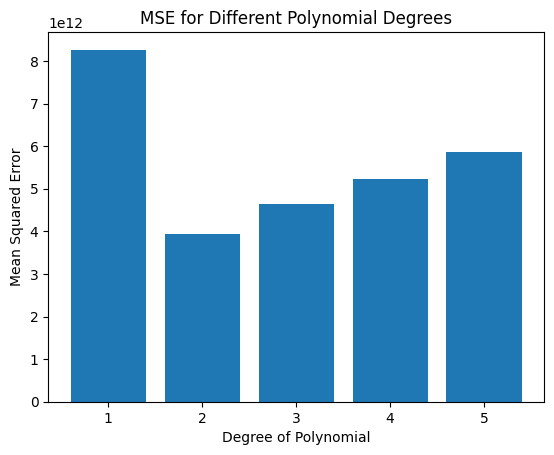

In [13]:
from sklearn.metrics import mean_squared_error

DEGREES = [1, 2, 3, 4, 5]

# Division des données en entraînement et test
x_train = df["year"][:40].values.reshape(-1, 1)
y_train = df["population"][:40].values

# test
x_test = df["year"][40:].values.reshape(-1, 1)
y_test = df["population"][40:].values

print("X_train:", x_train.flatten())
print("Y_train:", y_train.flatten())
print("X_test:", x_test.flatten())
print("Y_test:", y_test.flatten())

mse_values = []

for degree in DEGREES:
    # transformation polynomiale
    pf = PolynomialFeatures(degree=degree)
    x_poly_train = pf.fit_transform(x_train)
    
    # entraînement du modèle
    lr = LinearRegression()
    lr.fit(x_poly_train, y_train)
    
    # prédiction sur les données de test
    x_poly_test = pf.transform(x_test)
    y_predict = lr.predict(x_poly_test)
    
    # calcul de l'erreur quadratique moyenne
    mse = mean_squared_error(y_test, y_predict)
    mse_values.append(mse)
    print(f"Degree: {degree}, MSE: {mse}")
    
# Affichage des MSE pour chaque degré
plot.bar(DEGREES, mse_values)
plot.xlabel("Degree of Polynomial")
plot.ylabel("Mean Squared Error")
plot.title("MSE for Different Polynomial Degrees")
plot.show()

**Question 2 : Courbes d'apprentissage - Visualiser le sur-ajustement**

Créez un graphique de courbes d'apprentissage pour visualiser le sur-ajustement :

1. Pour les degrés polynomiaux 1, 2, 3, 5, 10 et 15 :
   - Calculez l'erreur d'entraînement (MSE sur les données d'entraînement)
   - Calculez l'erreur de test (MSE sur les données de test)

2. Créez un graphique avec :
   - Axe X : Degré polynomial
   - Axe Y : Erreur (MSE)
   - Deux lignes : Erreur d'entraînement et Erreur de test

3. Répondez à ces questions :
   - À quel degré le modèle commence-t-il à sur-ajuster ?
   - Que se passe-t-il avec l'erreur d'entraînement lorsque le degré augmente ?
   - Que se passe-t-il avec l'erreur de test lorsque le degré augmente ?

```python
from sklearn.metrics import mean_squared_error

degrees = [1, 2, 3, 5, 10, 15]
train_errors = []
test_errors = []

for degree in degrees:
    # Ajuster le modèle et calculer les erreurs
    # Votre code ici
    pass

# Tracer les courbes d'apprentissage
plt.plot(degrees, train_errors, label='Erreur d\'entraînement')
plt.plot(degrees, test_errors, label='Erreur de test')
plt.xlabel('Degré polynomial')
plt.ylabel('Erreur quadratique moyenne')
plt.legend()
plt.show()
```

Degree 1: train MSE = 2321723857841.885, test MSE = 8264668205806.573
Degree 2: train MSE = 473768677030.824, test MSE = 3941469937783.263
Degree 3: train MSE = 272594410496.254, test MSE = 4631928274631.703
Degree 5: train MSE = 263433239965.865, test MSE = 5855995750156.986
Degree 10: train MSE = 241222276508.609, test MSE = 9809654197901.855
Degree 15: train MSE = 221039801058.517, test MSE = 15136539576315.234


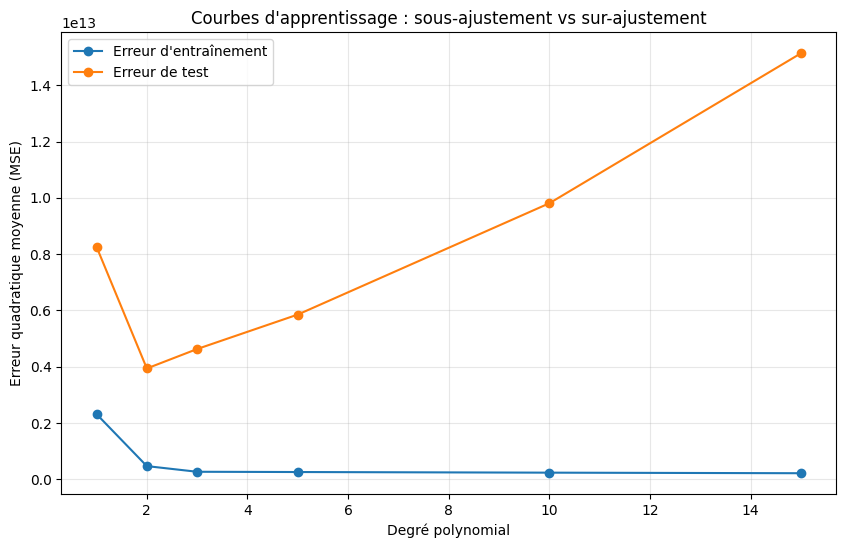

In [14]:
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import matplotlib.pyplot as plt

degrees = [1, 2, 3, 5, 10, 15]
train_errors = []
test_errors = []

x_train = df["year"][:40].values.reshape(-1, 1)
y_train = df["population"][:40].values
x_test = df["year"][40:].values.reshape(-1, 1)
y_test = df["population"][40:].values

for degree in degrees:
    polynomial = PolynomialFeatures(degree=degree)
    x_train_poly = polynomial.fit_transform(x_train)
    x_test_poly = polynomial.transform(x_test)

    model = LinearRegression()
    model.fit(x_train_poly, y_train)

    train_pred = model.predict(x_train_poly)
    test_pred = model.predict(x_test_poly)

    train_mse = mean_squared_error(y_train, train_pred)
    test_mse = mean_squared_error(y_test, test_pred)

    train_errors.append(train_mse)
    test_errors.append(test_mse)

    print(f"Degree {degree}: train MSE = {train_mse:.3f}, test MSE = {test_mse:.3f}")

plt.figure(figsize=(10, 6))
plt.plot(degrees, train_errors, marker='o', label="Erreur d'entraînement")
plt.plot(degrees, test_errors, marker='o', label='Erreur de test')
plt.xlabel('Degré polynomial')
plt.ylabel('Erreur quadratique moyenne (MSE)')
plt.title('Courbes d\'apprentissage : sous-ajustement vs sur-ajustement')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


`réponse:`

Sur cet exemple, on voit bien le passage d'un modèle trop simple à un modèle trop flexible.

- Pour un degré faible, le modèle reste très contraint. Il ne capture pas encore correctement la tendance générale des données, donc il sous-ajuste.
- Quand on augmente le degré, l'erreur d'entraînement baisse presque toujours, car le modèle devient plus capable de coller aux points observés.
- L'erreur de test, elle, diminue d'abord puis remonte dès que le modèle commence à apprendre le bruit plutôt que la structure réelle des données.

D'après les erreurs calculées sur les données du TP :

- degré 1 : MSE d'entraînement = 2.3217238578418853e+12, MSE de test = 8.264668205806573e+12
- degré 2 : MSE d'entraînement = 4.7376867703082355e+11, MSE de test = 3.941469937783263e+12
- degré 3 : MSE d'entraînement = 2.725944104962536e+11, MSE de test = 4.631928274631703e+12
- degré 5 : MSE d'entraînement = 2.6343323996586456e+11, MSE de test = 5.855995750156986e+12
- degré 10 : MSE d'entraînement = 2.4122227650860864e+11, MSE de test = 9.809654197901855e+12
- degré 15 : MSE d'entraînement = 2.210398010585171e+11, MSE de test = 1.5136539576315234e+13

- degré 2 : meilleur compromis observé ici, avec la plus faible erreur de test
- degré 3 et au-delà : l'erreur d'entraînement continue de baisser, mais l'erreur de test se dégrade, ce qui indique le début du sur-ajustement

Autrement dit, sur cet exercice, le sur-ajustement commence approximativement à partir du degré 3. Le degré 2 semble le plus pertinent, car il généralise mieux que les degrés plus élevés.

Conclusion pratique : plus le degré polynomial augmente, plus le modèle devient expressif. Cela améliore l'ajustement sur l'entraînement, mais au-delà d'un certain seuil, cela réduit la capacité de généralisation.


## Exercice 2 \[★★\]

Les classificateurs sont utiles pour classer notre ensemble de données dans une ou plusieurs classes. Mais contrairement aux algorithmes de regroupement, c'est l'utilisateur qui doit classer les données dans un algorithme de classification. Dans les exercices suivants, nous voyons différents classificateurs, en commençant par le perceptron. Regardez les données d'entrée (*numarray*) et les étiquettes associées (*resultat*). Ici, nous allons étiqueter l'ensemble des données et voir si notre modèle (Perceptron) a bien fonctionné.



In [ ]:
import numpy as np
import matplotlib.pyplot as plot
from sklearn.linear_model import Perceptron

numarray = np.array(
    [
        [0, 0, 0, 0],
        [0, 0, 0, 1],
        [0, 0, 1, 0],
        [0, 0, 1, 1],
        [0, 1, 0, 0],
        [0, 1, 0, 1],
        [0, 1, 1, 0],
        [0, 1, 1, 1],
        [1, 0, 0, 0],
        [1, 0, 0, 1],
        [1, 0, 1, 0],
        [1, 0, 1, 1],
        [1, 1, 0, 0],
        [1, 1, 0, 1],
        [1, 1, 1, 0],
        [1, 1, 1, 1],
    ]
)
result = np.array([0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1])

perceptron = Perceptron(max_iter=1000)
perceptron.fit(numarray, result)

x_predict = np.array([[0, 1, 0, 1], [1, 0, 1, 1]])

y_predict = perceptron.predict(x_predict)
y_predict

array([0, 1])

Nous allons maintenant supprimer certaines données étiquetées/classées et voir les résultats prévus.


In [15]:
import numpy as np
import matplotlib.pyplot as plot
from sklearn.linear_model import Perceptron

numarray = np.array(
    [
        [0, 0, 0, 0],
        [0, 0, 0, 1],
        [0, 1, 0, 0],
        [0, 1, 1, 1],
        [1, 0, 0, 1],
        [1, 0, 1, 0],
        [1, 1, 1, 0],
        [1, 1, 1, 1],
    ]
)
result = np.array([0, 0, 0, 0, 1, 1, 1, 1])

perceptron = Perceptron(max_iter=1000)
perceptron.fit(numarray, result)

x_predict = np.array([[0, 1, 0, 1], [1, 0, 1, 1], [1, 1, 0, 0], [0, 1, 0, 1]])

y_predict = perceptron.predict(x_predict)
y_predict

array([0, 1, 1, 0])

Maintenant, nous allons essayer un autre classificateur : MLPClassifier



In [16]:
import numpy as np
import matplotlib.pyplot as plot
from sklearn.neural_network import MLPClassifier

numarray = np.array(
    [
        [0, 0, 0, 0],
        [0, 0, 0, 1],
        [0, 1, 0, 0],
        [0, 1, 1, 1],
        [1, 0, 0, 1],
        [1, 0, 1, 0],
        [1, 1, 1, 0],
        [1, 1, 1, 1],
    ]
)

result = np.array([0, 0, 0, 0, 1, 1, 1, 1])

mlpclassifier = MLPClassifier(alpha=2, max_iter=1000)
mlpclassifier.fit(numarray, result)

x_predict = np.array([[0, 1, 0, 1], [1, 0, 1, 1], [1, 1, 0, 0], [0, 1, 0, 1]])

y_predict = mlpclassifier.predict(x_predict)
y_predict

array([0, 1, 1, 0])

Maintenant, nous allons essayer un autre classificateur utilisant des machines à vecteurs de support.


In [ ]:
import numpy as np
import matplotlib.pyplot as plot
from sklearn import svm

numarray = numarray = np.array(
    [
        [0, 0, 0, 0],
        [0, 0, 0, 1],
        [0, 1, 0, 0],
        [0, 1, 1, 1],
        [1, 0, 0, 1],
        [1, 0, 1, 0],
        [1, 1, 1, 0],
        [1, 1, 1, 1],
    ]
)

result = np.array([0, 0, 0, 0, 1, 1, 1, 1])

svcclassifier = svm.SVC(gamma=0.001, C=100.0)
svcclassifier.fit(numarray, result)

x_predict = np.array([[0, 1, 0, 1], [1, 0, 1, 1], [1, 1, 0, 0], [0, 1, 0, 1]])

y_predict = svcclassifier.predict(x_predict)
y_predict

array([0, 1, 1, 0])

Nous allons maintenant utiliser les données MNIST et les classificateurs vus précédemment pour reconnaître l'écriture manuscrite. Scikit-learn dispose d'un grand nombre de jeux de données. Nous allons utiliser un de ces jeux de données appelé *digits dataset*, qui est constitué d'images d'écriture manuscrite étiquetées de chiffres. Le programme suivant affichera les étiquettes.

In [15]:
from sklearn import datasets
import numpy as np

digits = datasets.load_digits()

print(np.unique(digits.target))

[0 1 2 3 4 5 6 7 8 9]


Nous allons maintenant voir le nombre total d'images et le contenu d'une image test.

Number of images:  115008
Input data:  [[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]]
Label: 0


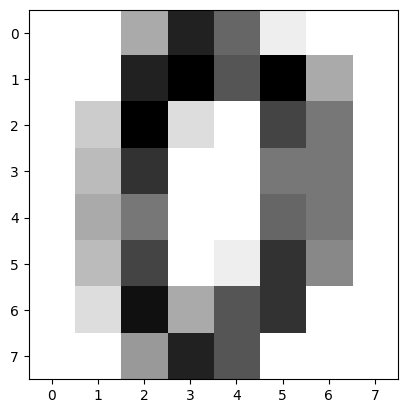

In [19]:
from sklearn import datasets
import numpy as np
import matplotlib.pyplot as plot

digits = datasets.load_digits()

print("Number of images: ", digits.images.size)
print("Input data: ", digits.images[0])
print("Label:", digits.target[0])

plot.imshow(digits.images[0], cmap=plot.cm.gray_r)
plot.show()

Nous allons maintenant utiliser un classificateur de vecteurs de support pour former les données. Nous allons diviser nos données en deux : les données d'entraînement et les données de test. N'oubliez pas que nous disposons déjà d'étiquettes pour l'ensemble des données.

Predicted value:  [4]


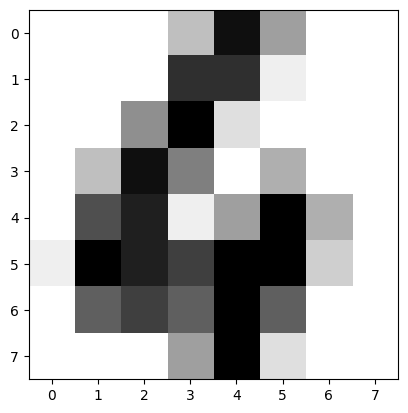

In [20]:
from sklearn import datasets, svm
import numpy as np
import matplotlib.pyplot as plot

digits = datasets.load_digits()

training_images = digits.images[: int(digits.images.shape[0] / 2)]
training_images = training_images.reshape((training_images.shape[0], -1))

training_target = digits.target[0 : int(digits.target.shape[0] / 2)]

classifier = svm.SVC(gamma=0.001, C=100.0)

# training
classifier.fit(training_images, training_target)

# prediction
predict_image = digits.images[int(digits.images.shape[0] / 2) + 2]
print("Predicted value: ", classifier.predict(predict_image.reshape(1, -1)))

plot.imshow(predict_image, cmap=plot.cm.gray_r)
plot.show()

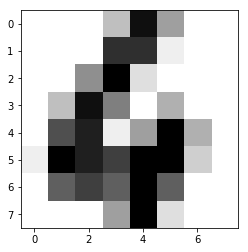

Essayons maintenant de prédire les étiquettes restantes et utilisons le rapport de classification pour obtenir la précision de la prédiction.

In [21]:
from sklearn import datasets, svm, metrics
import numpy as np
import matplotlib.pyplot as plot

digits = datasets.load_digits()

training_images = digits.images[: int(digits.images.shape[0] / 2)]
training_images = training_images.reshape((training_images.shape[0], -1))

training_target = digits.target[0 : int(digits.target.shape[0] / 2)]

classifier = svm.SVC(gamma=0.001, C=100.0)
# training
classifier.fit(training_images, training_target)

# prediction
predict_images = digits.images[int(digits.images.shape[0] / 2) + 1 :]
actual_labels = digits.target[int(digits.target.shape[0] / 2) + 1 :]
predicted_labels = classifier.predict(
    predict_images.reshape((predict_images.shape[0], -1))
)

# classification report
print(metrics.classification_report(actual_labels, predicted_labels))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99        88
           1       0.99      0.96      0.97        91
           2       0.99      0.99      0.99        86
           3       0.98      0.90      0.94        91
           4       0.99      0.96      0.97        92
           5       0.95      0.96      0.95        91
           6       0.99      0.99      0.99        91
           7       0.98      0.99      0.98        89
           8       0.94      1.00      0.97        87
           9       0.92      0.98      0.95        92

    accuracy                           0.97       898
   macro avg       0.97      0.97      0.97       898
weighted avg       0.97      0.97      0.97       898



Différence entre `precision`, `recall` et `f1-score` :

- **Précision (Precision)** : La précision mesure la proportion de prédictions positives correctes parmi toutes les prédictions positives faites par le modèle. En d'autres termes, c'est la capacité du modèle à ne pas classer à tort des échantillons négatifs comme positifs. La formule est : `Précision = TP / (TP + FP)`, où TP est le nombre de vrais positifs et FP est le nombre de faux positifs.

- **Rappel (Recall)** : Le rappel mesure la proportion de vrais positifs parmi tous les échantillons qui sont réellement positifs. En d'autres termes, c'est la capacité du modèle à trouver tous les échantillons positifs. La formule est : `Rappel = TP / (TP + FN)`, où FN est le nombre de faux négatifs.

- **F1-Score** : Le F1-score est la moyenne harmonique de la précision et du rappel. Il fournit une mesure unique qui combine à la fois la précision et le rappel, ce qui est particulièrement utile lorsque les classes sont déséquilibrées. La formule est : `F1-Score = 2 * (Précision * Rappel) / (Précision + Rappel)`. Un F1-score élevé indique que le modèle a à la fois une bonne précision et un bon rappel.

Grossomodo, une `precision` élevée signifie que lorsque le modèle prédit une classe positive, il a raison la plupart du temps. Un `recall` élevé signifie que le modèle trouve la plupart des échantillons positifs réels. Le `f1-score` combine ces deux aspects pour donner une mesure globale de la performance du modèle, surtout dans les cas où les classes sont déséquilibrées.

Il existe d'autres classificateurs. Nous allons maintenant travailler avec Perceptron (voir [ici](http://scikit-learn.org/stable/modules/linear_model.html#perceptron)) et voir ses performances.

In [22]:
from sklearn import datasets, metrics
from sklearn.linear_model import Perceptron
import numpy as np
import matplotlib.pyplot as plot

digits = datasets.load_digits()

training_images = digits.images[: int(digits.images.shape[0] / 2)]
training_images = training_images.reshape((training_images.shape[0], -1))

training_target = digits.target[0 : int(digits.target.shape[0] / 2)]

classifier = Perceptron(max_iter=1000)
# training
classifier.fit(training_images, training_target)

# prediction
predict_images = digits.images[int(digits.images.shape[0] / 2) + 1 :]
actual_labels = digits.target[int(digits.target.shape[0] / 2) + 1 :]
predicted_labels = classifier.predict(
    predict_images.reshape((predict_images.shape[0], -1))
)

# classification report
print(metrics.classification_report(actual_labels, predicted_labels))

              precision    recall  f1-score   support

           0       0.91      0.98      0.94        88
           1       0.79      0.91      0.85        91
           2       0.98      0.97      0.97        86
           3       0.95      0.84      0.89        91
           4       0.95      0.90      0.93        92
           5       0.83      0.92      0.88        91
           6       0.97      0.99      0.98        91
           7       0.98      0.92      0.95        89
           8       0.94      0.74      0.83        87
           9       0.83      0.90      0.86        92

    accuracy                           0.91       898
   macro avg       0.91      0.91      0.91       898
weighted avg       0.91      0.91      0.91       898



Enfin, nous terminerons le test avec le Perceptron multicouche (voir
[ici](http://scikit-learn.org/stable/modules/neural_networks_supervised.html#multi-layer-perceptron)).

In [18]:
from sklearn import datasets, metrics
from sklearn.neural_network import MLPClassifier
import numpy as np
import matplotlib.pyplot as plot

digits = datasets.load_digits()

training_images = digits.images[: int(digits.images.shape[0] / 2)]
training_images = training_images.reshape((training_images.shape[0], -1))

training_target = digits.target[0 : int(digits.target.shape[0] / 2)]

classifier = MLPClassifier(alpha=2, max_iter=1000)
# training
classifier.fit(training_images, training_target)

# prediction
predict_images = digits.images[int(digits.images.shape[0] / 2) + 1 :]
actual_labels = digits.target[int(digits.target.shape[0] / 2) + 1 :]
predicted_labels = classifier.predict(
    predict_images.reshape((predict_images.shape[0], -1))
)

# classification report
print(metrics.classification_report(actual_labels, predicted_labels))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99        88
           1       0.95      0.91      0.93        91
           2       1.00      1.00      1.00        86
           3       0.97      0.85      0.91        91
           4       0.99      0.92      0.96        92
           5       0.92      0.96      0.94        91
           6       0.95      0.99      0.97        91
           7       0.98      0.99      0.98        89
           8       0.90      0.94      0.92        87
           9       0.86      0.97      0.91        92

    accuracy                           0.95       898
   macro avg       0.95      0.95      0.95       898
weighted avg       0.95      0.95      0.95       898



**Question 1 : Expérimentation avec MLPClassifier**

Le `MLPClassifier` a un paramètre `hidden_layer_sizes` qui contrôle l'architecture du réseau.

Essayez les configurations suivantes et enregistrez la précision :
- `hidden_layer_sizes=(50,)` - une couche cachée avec 50 neurones
- `hidden_layer_sizes=(100,)` - une couche cachée avec 100 neurones  
- `hidden_layer_sizes=(50, 50)` - deux couches cachées avec 50 neurones chacune
- `hidden_layer_sizes=(100, 50, 25)` - trois couches cachées

Quelles sont vos observations ? Ajouter plus de couches ou de neurones améliore-t-il toujours la précision ?

In [19]:
from sklearn import datasets, metrics
from sklearn.neural_network import MLPClassifier
import numpy as np
import matplotlib.pyplot as plot

digits = datasets.load_digits()

layer_sizes = [
    (50,),
    (100,),
    (50, 50),
    (100, 50, 25),
]


for size in layer_sizes:
    training_images = digits.images[: int(digits.images.shape[0] / 2)]
    training_images = training_images.reshape((training_images.shape[0], -1))

    training_target = digits.target[0 : int(digits.target.shape[0] / 2)]
    classifier = MLPClassifier(alpha=2, max_iter=1000, hidden_layer_sizes=size)
    # training
    classifier.fit(training_images, training_target)

    # prediction
    predict_images = digits.images[int(digits.images.shape[0] / 2) + 1 :]
    actual_labels = digits.target[int(digits.target.shape[0] / 2) + 1 :]
    predicted_labels = classifier.predict(
        predict_images.reshape((predict_images.shape[0], -1))
    )

    # classification report
    print(metrics.classification_report(actual_labels, predicted_labels))


              precision    recall  f1-score   support

           0       1.00      0.98      0.99        88
           1       0.92      0.91      0.92        91
           2       1.00      0.99      0.99        86
           3       0.96      0.84      0.89        91
           4       0.99      0.92      0.96        92
           5       0.91      0.95      0.93        91
           6       0.95      0.99      0.97        91
           7       0.98      0.98      0.98        89
           8       0.90      0.94      0.92        87
           9       0.86      0.97      0.91        92

    accuracy                           0.95       898
   macro avg       0.95      0.95      0.95       898
weighted avg       0.95      0.95      0.95       898

              precision    recall  f1-score   support

           0       1.00      0.98      0.99        88
           1       0.95      0.91      0.93        91
           2       1.00      0.99      0.99        86
           3       0.96 

**Question 2 : Validation croisée pour une évaluation robuste**

Au lieu d'une seule division entraînement/test, utilisez la validation croisée K-Fold pour obtenir une estimation de précision plus fiable :

```python
from sklearn.model_selection import cross_val_score

# Utilisation de la validation croisée 5-fold
classifier = svm.SVC(gamma=0.001, C=100.0)
images_flat = digits.images.reshape((digits.images.shape[0], -1))

scores = cross_val_score(classifier, images_flat, digits.target, cv=5)
print(f"Précision : {scores.mean():.3f} (+/- {scores.std()*2:.3f})")
```

1. Exécutez la validation croisée 5-fold pour SVM, Perceptron et MLPClassifier
2. Comparez la précision moyenne et l'écart-type pour chacun
3. Quel classificateur donne les résultats les plus cohérents (écart-type le plus bas) ?

In [21]:
from sklearn.model_selection import cross_val_score
from sklearn import svm
from sklearn.linear_model import Perceptron
from sklearn.neural_network import MLPClassifier

# Données (digits est déjà chargé dans le notebook)
images_flat = digits.images.reshape((digits.images.shape[0], -1))
y = digits.target

models = {
    "SVM": svm.SVC(gamma=0.001, C=100.0),
    "Perceptron": Perceptron(max_iter=1000, random_state=42),
    "MLPClassifier": MLPClassifier(hidden_layer_sizes=(100,), alpha=2, max_iter=1000, random_state=42),
}

results = {}

for name, model in models.items():
    scores = cross_val_score(model, images_flat, y, cv=5, scoring="accuracy")
    results[name] = {"mean": scores.mean(), "std": scores.std()}
    print(f"{name:<13} -> Accuracy: {scores.mean():.3f} (+/- {scores.std()*2:.3f})")

# Comparaison de cohérence (plus petit écart-type)
most_consistent = min(results, key=lambda k: results[k]["std"])
print(f"\nClassificateur le plus cohérent (écart-type le plus bas) : {most_consistent}")

SVM           -> Accuracy: 0.972 (+/- 0.027)
Perceptron    -> Accuracy: 0.901 (+/- 0.078)
MLPClassifier -> Accuracy: 0.947 (+/- 0.052)

Classificateur le plus cohérent (écart-type le plus bas) : SVM


**Question 3 : Matrice de confusion**

Tracez la matrice de confusion pour chaque classificateur en utilisant :
```python
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(actual_labels, predicted_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
```

Quels chiffres sont le plus souvent confondus entre eux ? Pourquoi cela pourrait-il être le cas ?

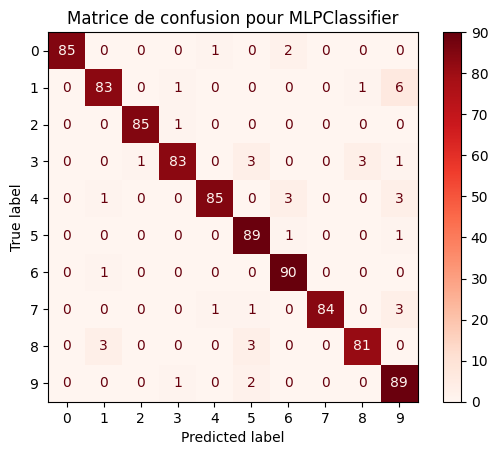

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(actual_labels, predicted_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classifier.classes_)
disp.plot(cmap=plt.cm.Reds)
plt.title("Matrice de confusion pour MLPClassifier")
plt.show()

On s'appercoit que les chiffres 8 et 9 sont souvent confondus, probablement en raison de leur similarité visuelle dans certaines écritures manuscrites. De même, les chiffres 3 et 5 peuvent être confondus pour des raisons similaires. Analyser la matrice de confusion peut aider à identifier les classes qui posent le plus de problèmes au modèle et à orienter les efforts d'amélioration.

**Question 4 : Utilisation de train_test_split**

Refactorisez le code pour utiliser `train_test_split` de sklearn au lieu d'une division manuelle :

```python
from sklearn.model_selection import train_test_split

X = digits.images.reshape((digits.images.shape[0], -1))
y = digits.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
```

Pourquoi l'utilisation de `random_state` est-elle importante pour la reproductibilité ?

Classification Report for SVM:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       1.00      1.00      1.00        50
           2       1.00      1.00      1.00        47
           3       0.98      0.96      0.97        54
           4       1.00      1.00      1.00        60
           5       0.99      1.00      0.99        66
           6       1.00      1.00      1.00        53
           7       0.98      0.98      0.98        55
           8       0.98      1.00      0.99        43
           9       0.98      0.97      0.97        59

    accuracy                           0.99       540
   macro avg       0.99      0.99      0.99       540
weighted avg       0.99      0.99      0.99       540




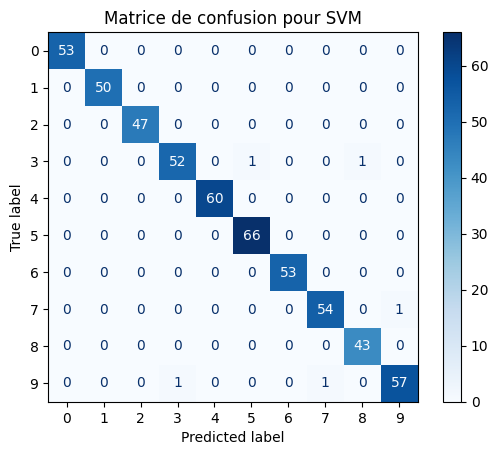

Classification Report for Perceptron:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        53
           1       0.97      0.62      0.76        50
           2       0.94      0.98      0.96        47
           3       0.98      0.93      0.95        54
           4       0.95      0.98      0.97        60
           5       0.98      0.91      0.94        66
           6       0.98      0.98      0.98        53
           7       0.96      0.98      0.97        55
           8       0.65      0.95      0.77        43
           9       0.87      0.92      0.89        59

    accuracy                           0.92       540
   macro avg       0.93      0.92      0.92       540
weighted avg       0.94      0.92      0.92       540




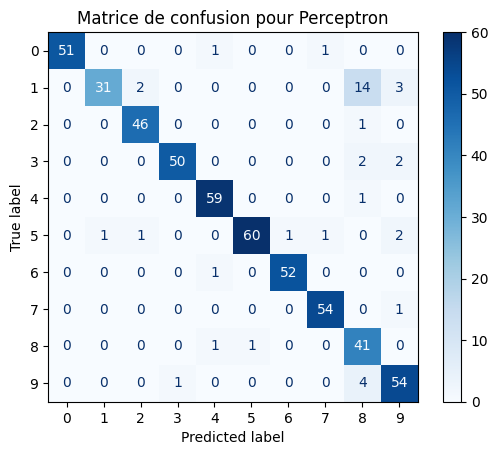

Classification Report for MLPClassifier:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       0.96      1.00      0.98        50
           2       0.98      1.00      0.99        47
           3       0.98      0.96      0.97        54
           4       0.98      1.00      0.99        60
           5       0.95      0.95      0.95        66
           6       0.98      0.98      0.98        53
           7       0.98      0.98      0.98        55
           8       1.00      0.93      0.96        43
           9       0.97      0.97      0.97        59

    accuracy                           0.98       540
   macro avg       0.98      0.98      0.98       540
weighted avg       0.98      0.98      0.98       540




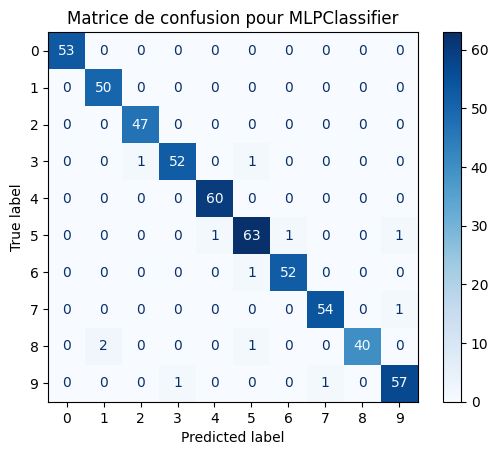

In [ ]:
from sklearn.model_selection import train_test_split

# import different models
from sklearn import svm
from sklearn.linear_model import Perceptron
from sklearn.neural_network import MLPClassifier

# import evaluation metrics
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score

X = digits.images.reshape((digits.images.shape[0], -1))
y = digits.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


models = {
    "SVM": svm.SVC(gamma=0.001, C=100.0),
    "Perceptron": Perceptron(max_iter=1000, random_state=42),
    "MLPClassifier": MLPClassifier(hidden_layer_sizes=(100,), alpha=2, max_iter=1000, random_state=42),
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        "classification_report": classification_report(y_test, y_pred),
        "confusion_matrix": confusion_matrix(y_test, y_pred),
    }
    print(f"Classification Report for {name}:\n{results[name]['classification_report']}\n")
    
    disp = ConfusionMatrixDisplay(confusion_matrix=results[name]["confusion_matrix"], display_labels=model.classes_)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Matrice de confusion pour {name}")
    plt.show()

## Exercice 3 \[★★\]

Nous allons d'abord construire un classificateur d'arbres de décision en utilisant un exemple très simple. Comme les classificateurs que nous avons vus auparavant, nous essaierons d'abord de faire correspondre nos données et ensuite de prédire une classe pour une valeur jamais vue auparavant.



In [24]:
from sklearn import tree

data = [[0, 0], [1, 1], [1, 0]]

result = [1, 0, 1]
dtc = tree.DecisionTreeClassifier()
dtc = dtc.fit(data, result)
dtc.predict([[1, 1]])

array([0])

Notre prochain objectif est de visualiser l'arbre de décision. Regardez le code suivant et voyez comment nous avons donné des noms aux deux colonnes des données ci-dessus. Nous avons également donné des noms aux entrées de données *résultat*, en les appelant *classe1* et *classe2*.

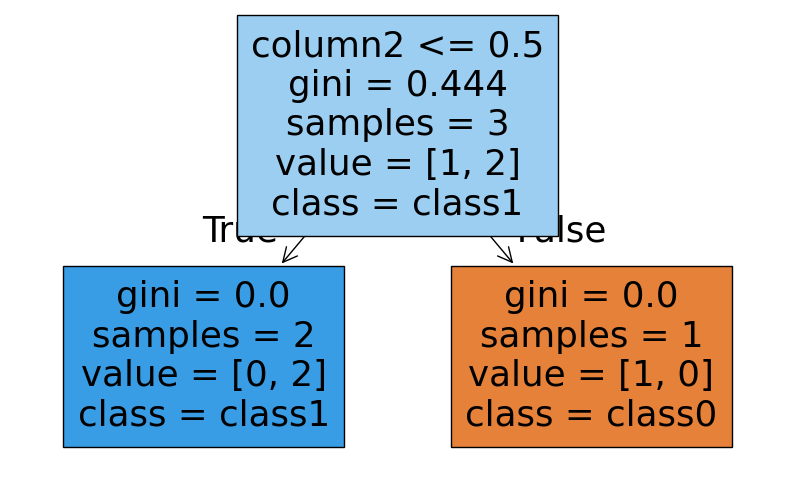

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

X = np.array([[0, 0], [1, 1], [1, 0]])
y = np.array([1, 0, 1])

dtc = DecisionTreeClassifier()
dtc.fit(X, y)

plt.figure(figsize=(10, 6))
plot_tree(
    dtc,
    feature_names=["column1", "column2"],
    class_names=["class0", "class1"],
    filled=True
)
plt.show()

Prenons maintenant un exemple réaliste. Dans le code suivant, nous considérons 13 photos marquées par un utilisateur comme "Favorite" et "NotFavorite". Pour chaque photo, nous avons quatre caractéristiques :
- **color** : couleur prédominante (green, blue, yellow, red)
- **tag** : sujet (nature, architecture, people)
- **size** : taille de l'image (medium, thumbnail)
- **mode** : orientation (portrait, landscape)

Nous allons construire un classificateur d'arbre de décision avec ces données et prédire si l'utilisateur aimera une nouvelle photographie.

### Pourquoi utiliser LabelEncoder ?

Les algorithmes d'apprentissage automatique travaillent avec des nombres, pas du texte. `LabelEncoder` convertit les valeurs textuelles catégorielles en étiquettes numériques :
- `["blue", "green", "red", "yellow"]` → `[0, 1, 2, 3]`
- `["Favorite", "NotFavorite"]` → `[0, 1]`

Cela permet à l'arbre de décision de traiter les données mathématiquement.

In [26]:
from sklearn import tree
import pandas as pd
from sklearn.preprocessing import LabelEncoder

data = [
    ["green", "nature", "thumbnail", "landscape"],
    ["blue", "architecture", "medium", "portrait"],
    ["blue", "people", "medium", "landscape"],
    ["yellow", "nature", "medium", "portrait"],
    ["green", "nature", "thumbnail", "landscape"],
    ["blue", "people", "medium", "landscape"],
    ["blue", "nature", "thumbnail", "portrait"],
    ["yellow", "architecture", "thumbnail", "landscape"],
    ["blue", "people", "medium", "portrait"],
    ["yellow", "nature", "medium", "landscape"],
    ["yellow", "people", "thumbnail", "portrait"],
    ["blue", "people", "medium", "landscape"],
    ["red", "architecture", "thumbnail", "landscape"],
]
result = [
    "Favorite",
    "NotFavorite",
    "Favorite",
    "Favorite",
    "Favorite",
    "Favorite",
    "Favorite",
    "NotFavorite",
    "NotFavorite",
    "Favorite",
    "Favorite",
    "NotFavorite",
    "NotFavorite",
]


# creating dataframes
dataframe = pd.DataFrame(data, columns=["color", "tag", "size", "mode"])
resultframe = pd.DataFrame(result, columns=["favorite"])

# generating numerical labels
le1 = LabelEncoder()
dataframe["color"] = le1.fit_transform(dataframe["color"])

le2 = LabelEncoder()
dataframe["tag"] = le2.fit_transform(dataframe["tag"])

le3 = LabelEncoder()
dataframe["size"] = le3.fit_transform(dataframe["size"])

le4 = LabelEncoder()
dataframe["mode"] = le4.fit_transform(dataframe["mode"])

le5 = LabelEncoder()
resultframe["favorite"] = le5.fit_transform(resultframe["favorite"])

# Use of decision tree classifiers
dtc = tree.DecisionTreeClassifier()
dtc = dtc.fit(dataframe.values, resultframe)

# prediction
prediction = dtc.predict(
    [
        [
            le1.transform(["red"])[0],
            le2.transform(["nature"])[0],
            le3.transform(["thumbnail"])[0],
            le4.transform(["portrait"])[0],
        ]
    ]
)
print(le5.inverse_transform(prediction))
print(dtc.feature_importances_)

['Favorite']
[0.16595745 0.69574468 0.         0.13829787]


**Quelles sont vos observations ?**

Regardez la sortie :
1. **Prédiction** : "NotFavorite" a-t-il du sens pour une photo rouge de nature en miniature en mode portrait ?
2. **Importance des caractéristiques** : Le tableau montre l'importance de chaque caractéristique [color, tag, size, mode]
   - Quelle caractéristique a l'importance la plus élevée ?
   - Quelle caractéristique a l'importance la plus basse ?
   - Est-ce que cela correspond à votre intuition sur ce qui rend une photo "Favorite" ?

**Idée clé** : L'importance des caractéristiques nous aide à comprendre quels attributs influencent le plus les décisions du modèle. C'est utile pour :
- Comprendre le comportement du modèle
- La sélection des caractéristiques (supprimer les caractéristiques non importantes)
- Expliquer les prédictions aux parties prenantes

Notre prochain objectif est de visualiser l'arbre de décision ci-dessus. Testez le code ci-dessous. Il est similaire au code que nous avons testé auparavant. Regardez les classes et les caractéristiques.

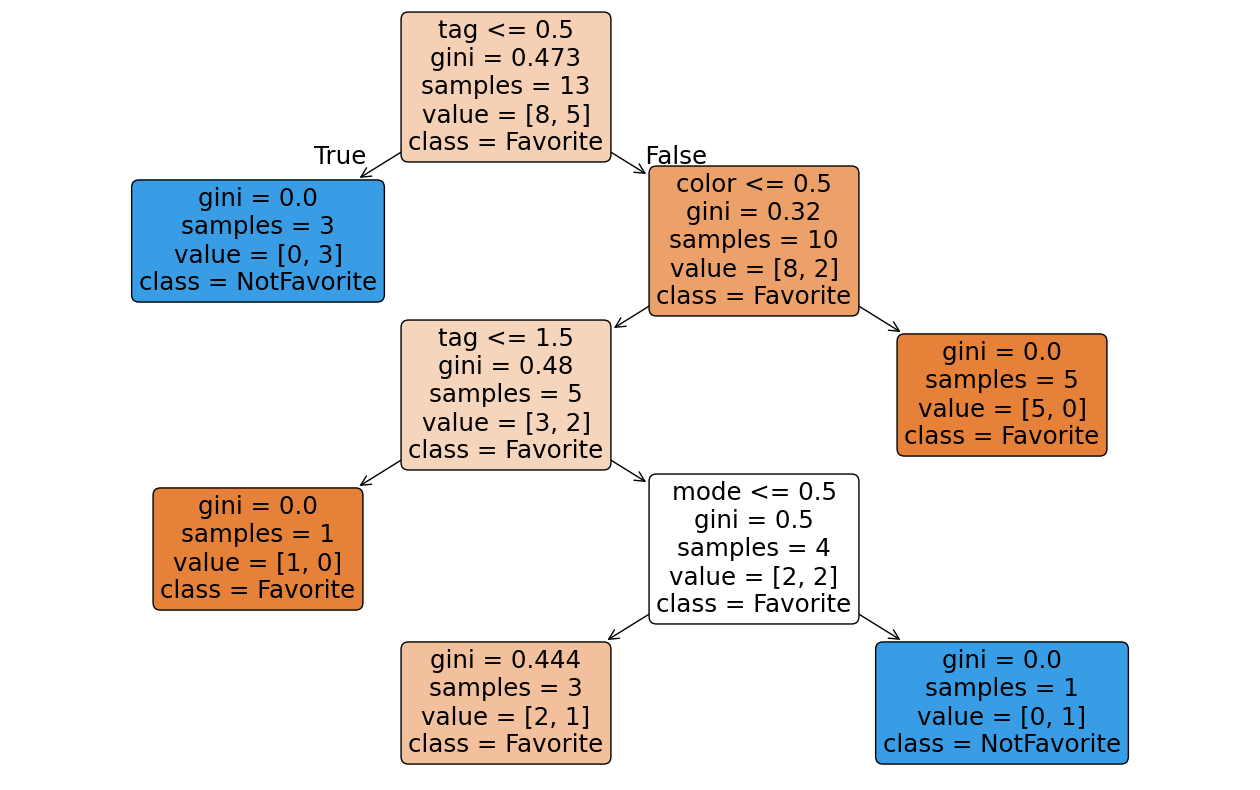

In [27]:
from sklearn import tree
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from IPython.display import Image, display

data = [
    ["green", "nature", "thumbnail", "landscape"],
    ["blue", "architecture", "medium", "portrait"],
    ["blue", "people", "medium", "landscape"],
    ["yellow", "nature", "medium", "portrait"],
    ["green", "nature", "thumbnail", "landscape"],
    ["blue", "people", "medium", "landscape"],
    ["blue", "nature", "thumbnail", "portrait"],
    ["yellow", "architecture", "thumbnail", "landscape"],
    ["blue", "people", "medium", "portrait"],
    ["yellow", "nature", "medium", "landscape"],
    ["yellow", "people", "thumbnail", "portrait"],
    ["blue", "people", "medium", "landscape"],
    ["red", "architecture", "thumbnail", "landscape"],
]
result = [
    "Favorite",
    "NotFavorite",
    "Favorite",
    "Favorite",
    "Favorite",
    "Favorite",
    "Favorite",
    "NotFavorite",
    "NotFavorite",
    "Favorite",
    "Favorite",
    "NotFavorite",
    "NotFavorite",
]


# creating dataframes
dataframe = pd.DataFrame(data, columns=["color", "tag", "size", "mode"])
resultframe = pd.DataFrame(result, columns=["favorite"])

# generating numerical labels
le1 = LabelEncoder()
dataframe["color"] = le1.fit_transform(dataframe["color"])

le2 = LabelEncoder()
dataframe["tag"] = le2.fit_transform(dataframe["tag"])

le3 = LabelEncoder()
dataframe["size"] = le3.fit_transform(dataframe["size"])

le4 = LabelEncoder()
dataframe["mode"] = le4.fit_transform(dataframe["mode"])

le5 = LabelEncoder()
resultframe["favorite"] = le5.fit_transform(resultframe["favorite"])

# Use of decision tree classifiers

dtc = tree.DecisionTreeClassifier()
dtc.fit(dataframe, resultframe)

plt.figure(figsize=(16, 10))
tree.plot_tree(
    dtc,
    feature_names=dataframe.columns,
    class_names=le5.inverse_transform(resultframe.favorite.unique()),
    filled=True,
    rounded=True
)
plt.show()

Et si nous avions la possibilité d'avoir plusieurs arbres de décision ? Prévoyons en utilisant un classificateur forestier aléatoire (qui peut être considéré comme une collection d'arbres décisionnels multiples). Vérifiez la valeur prédite ainsi que l'importance des différentes caractéristiques. Notez que nous demandons de créer 10 estimateurs de ce type en utilisant une profondeur maximale de 2 pour chacun des estimateurs.


In [28]:
from sklearn import tree
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from IPython.display import Image, display

data = [
    ["green", "nature", "thumbnail", "landscape"],
    ["blue", "architecture", "medium", "portrait"],
    ["blue", "people", "medium", "landscape"],
    ["yellow", "nature", "medium", "portrait"],
    ["green", "nature", "thumbnail", "landscape"],
    ["blue", "people", "medium", "landscape"],
    ["blue", "nature", "thumbnail", "portrait"],
    ["yellow", "architecture", "thumbnail", "landscape"],
    ["blue", "people", "medium", "portrait"],
    ["yellow", "nature", "medium", "landscape"],
    ["yellow", "people", "thumbnail", "portrait"],
    ["blue", "people", "medium", "landscape"],
    ["red", "architecture", "thumbnail", "landscape"],
]
result = [
    "Favorite",
    "NotFavorite",
    "Favorite",
    "Favorite",
    "Favorite",
    "Favorite",
    "Favorite",
    "NotFavorite",
    "NotFavorite",
    "Favorite",
    "Favorite",
    "NotFavorite",
    "NotFavorite",
]


# creating dataframes
dataframe = pd.DataFrame(data, columns=["color", "tag", "size", "mode"])
resultframe = pd.DataFrame(result, columns=["favorite"])

# generating numerical labels
le1 = LabelEncoder()
dataframe["color"] = le1.fit_transform(dataframe["color"])

le2 = LabelEncoder()
dataframe["tag"] = le2.fit_transform(dataframe["tag"])

le3 = LabelEncoder()
dataframe["size"] = le3.fit_transform(dataframe["size"])

le4 = LabelEncoder()
dataframe["mode"] = le4.fit_transform(dataframe["mode"])

le5 = LabelEncoder()
resultframe["favorite"] = le5.fit_transform(resultframe["favorite"])

# Use of random forest classifier
rfc = RandomForestClassifier(n_estimators=10, max_depth=2, random_state=0)
rfc = rfc.fit(dataframe.values, resultframe.values.ravel())

# prediction
prediction = rfc.predict(
    [
        [
            le1.transform(["red"])[0],
            le2.transform(["nature"])[0],
            le3.transform(["thumbnail"])[0],
            le4.transform(["portrait"])[0],
        ]
    ]
)
print(le5.inverse_transform(prediction))
print(rfc.feature_importances_)

['Favorite']
[0.28475872 0.54335851 0.10117429 0.07070848]


Enfin, nous visualisons ces estimateurs.

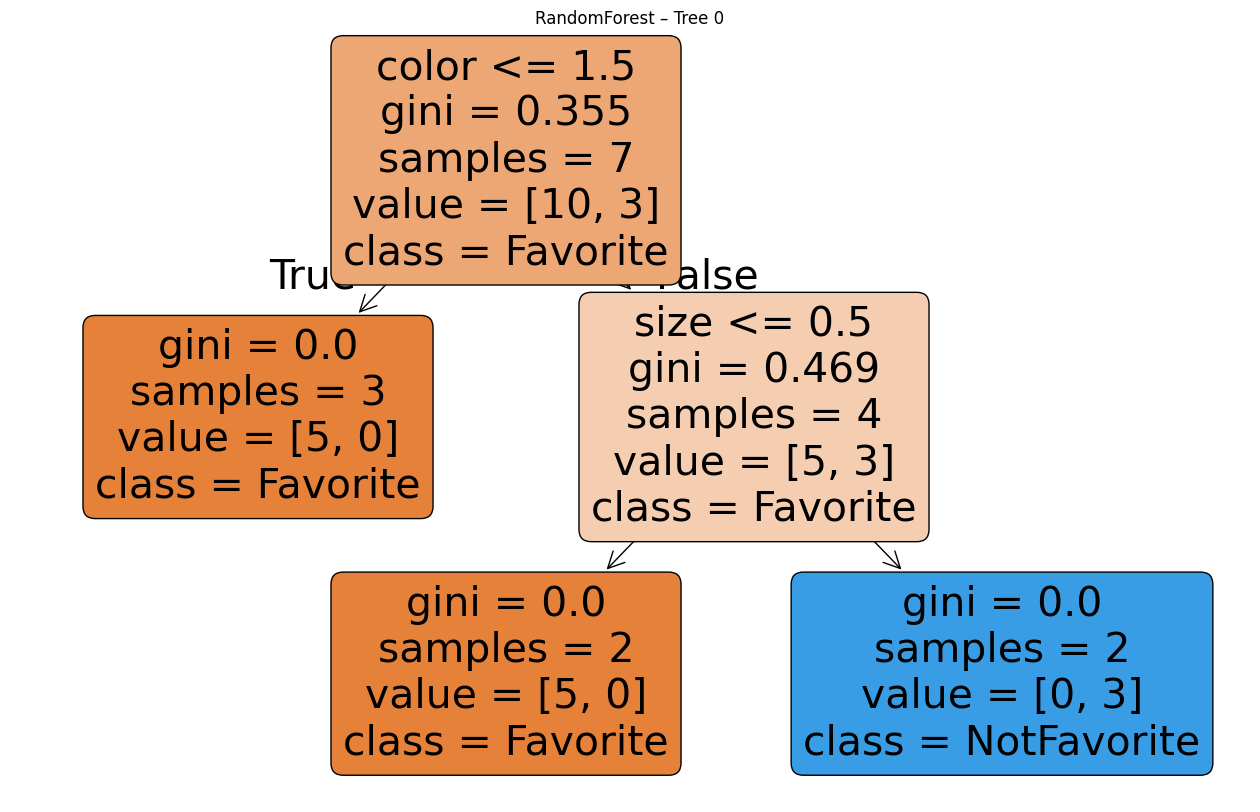

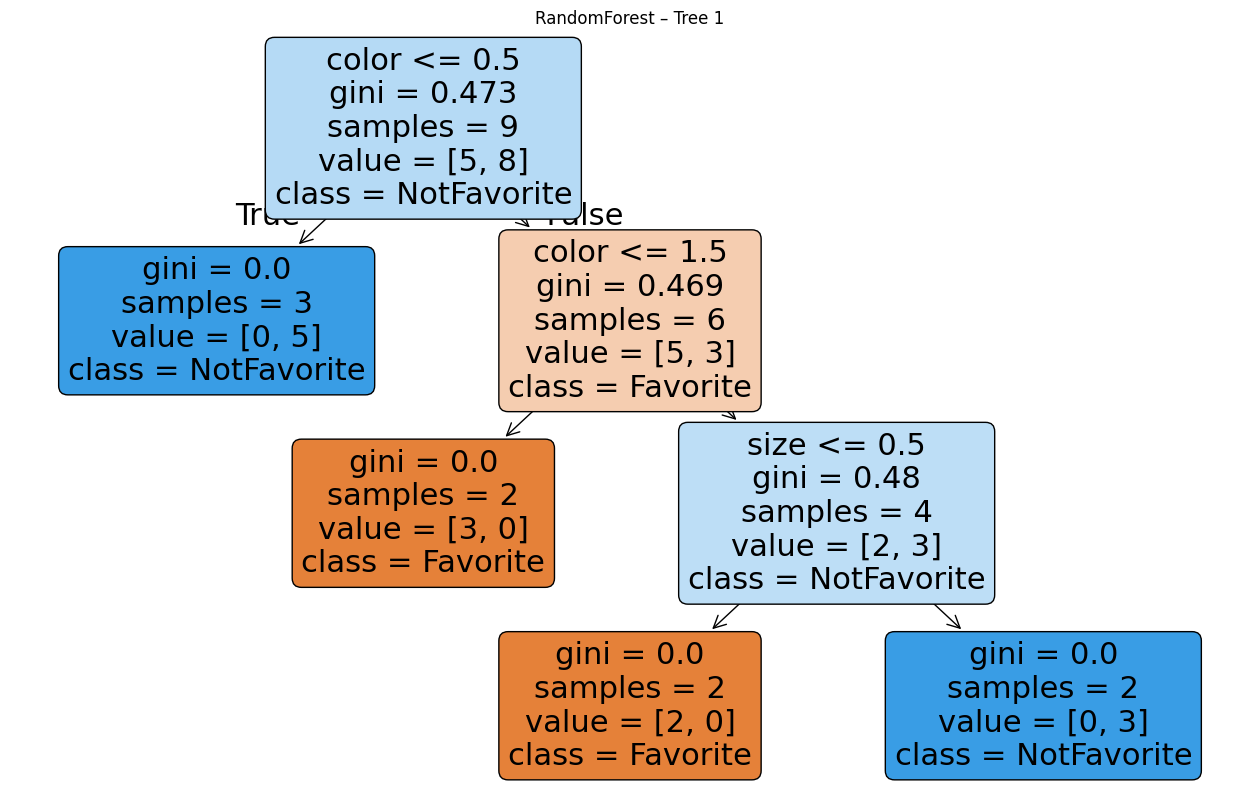

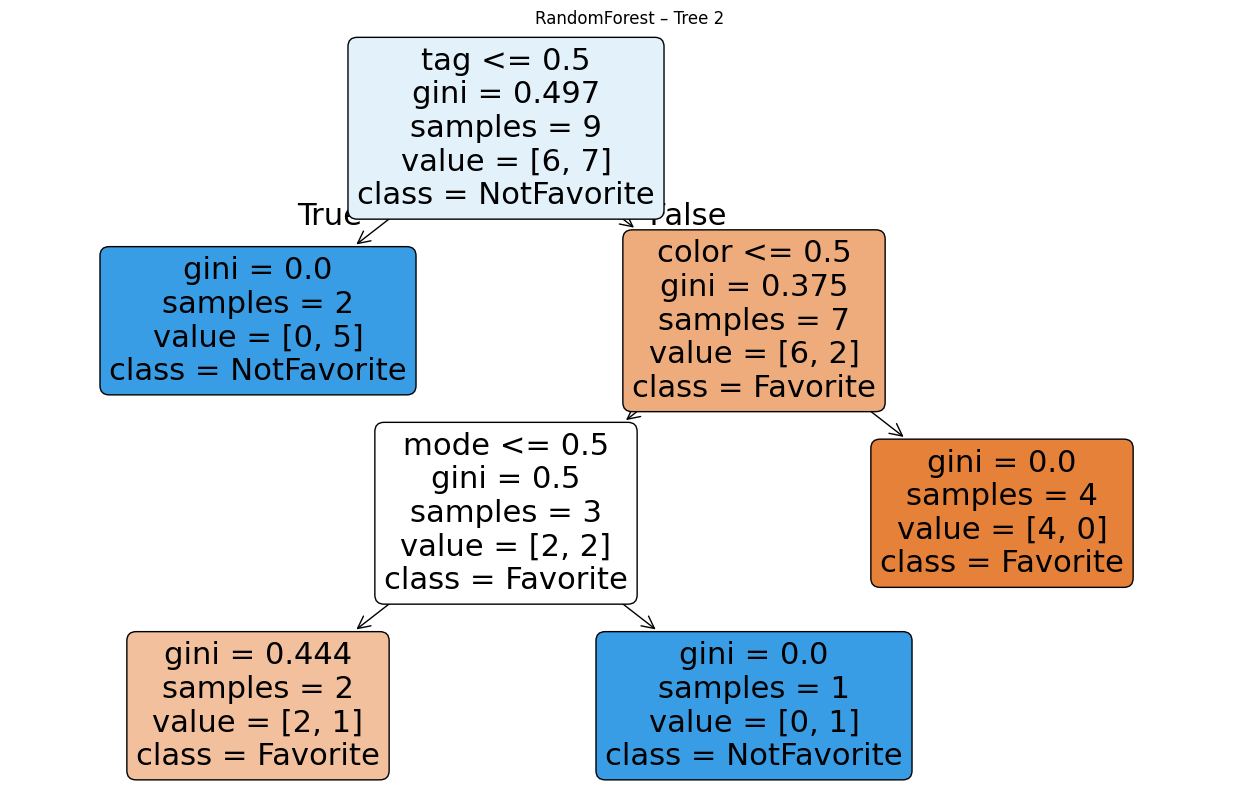

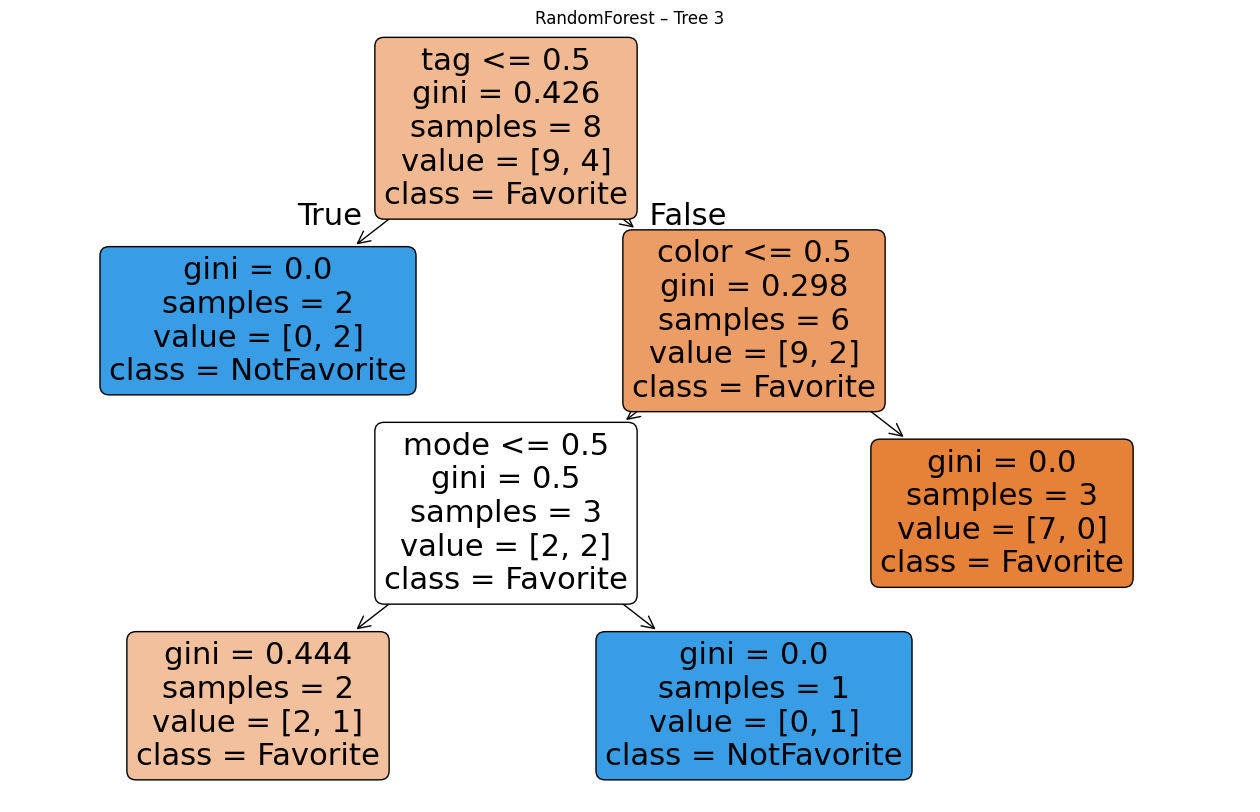

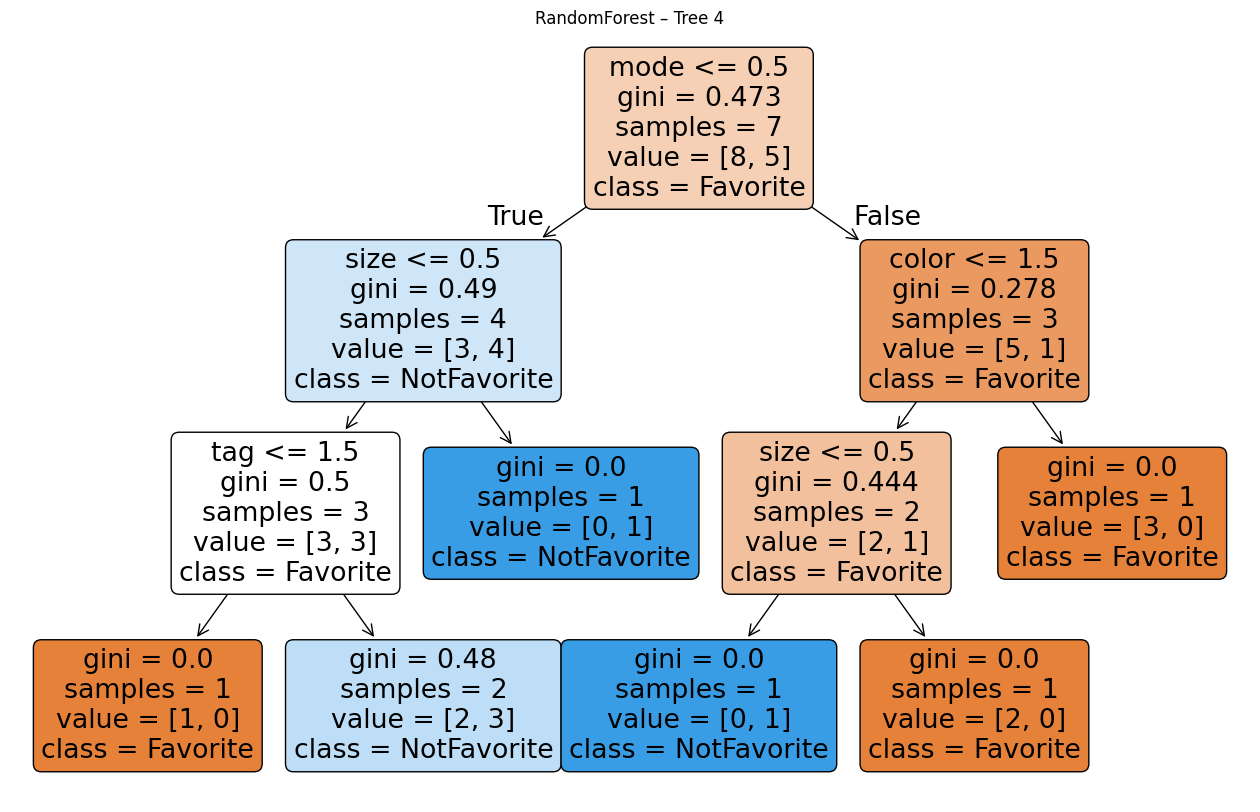

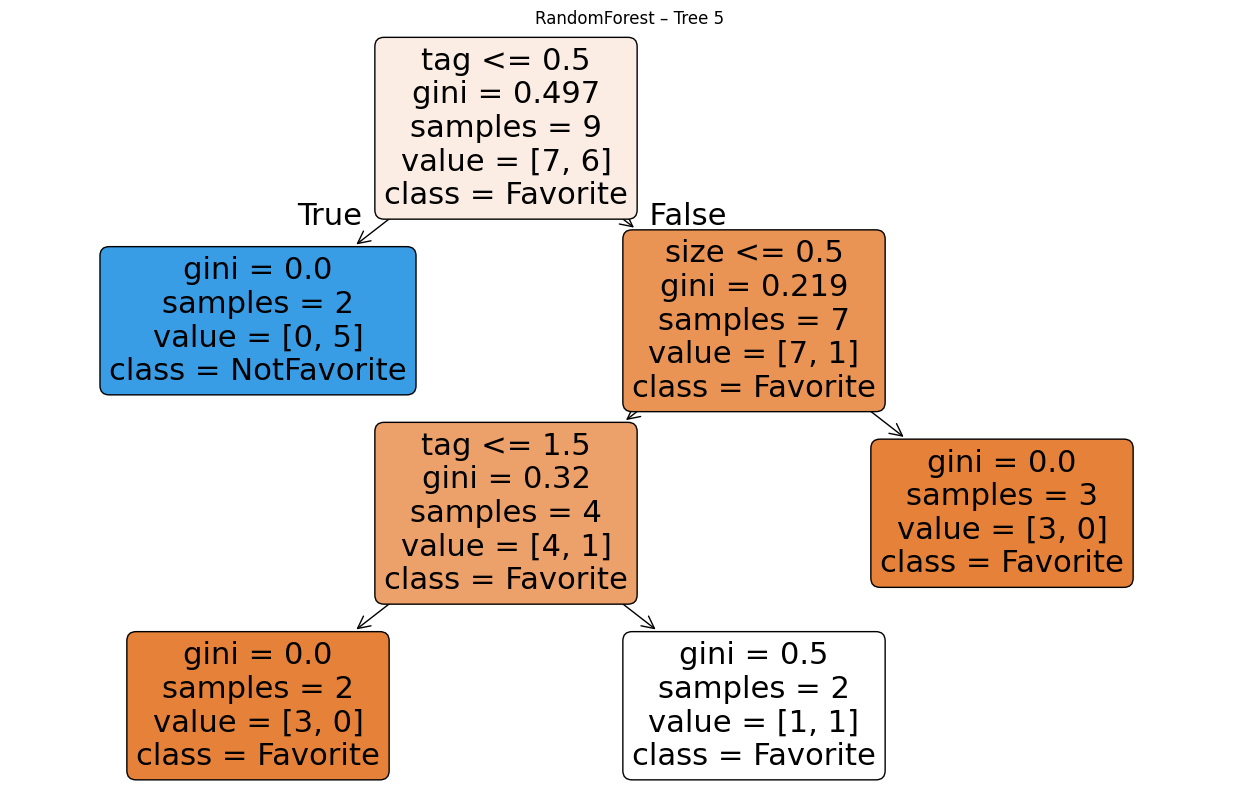

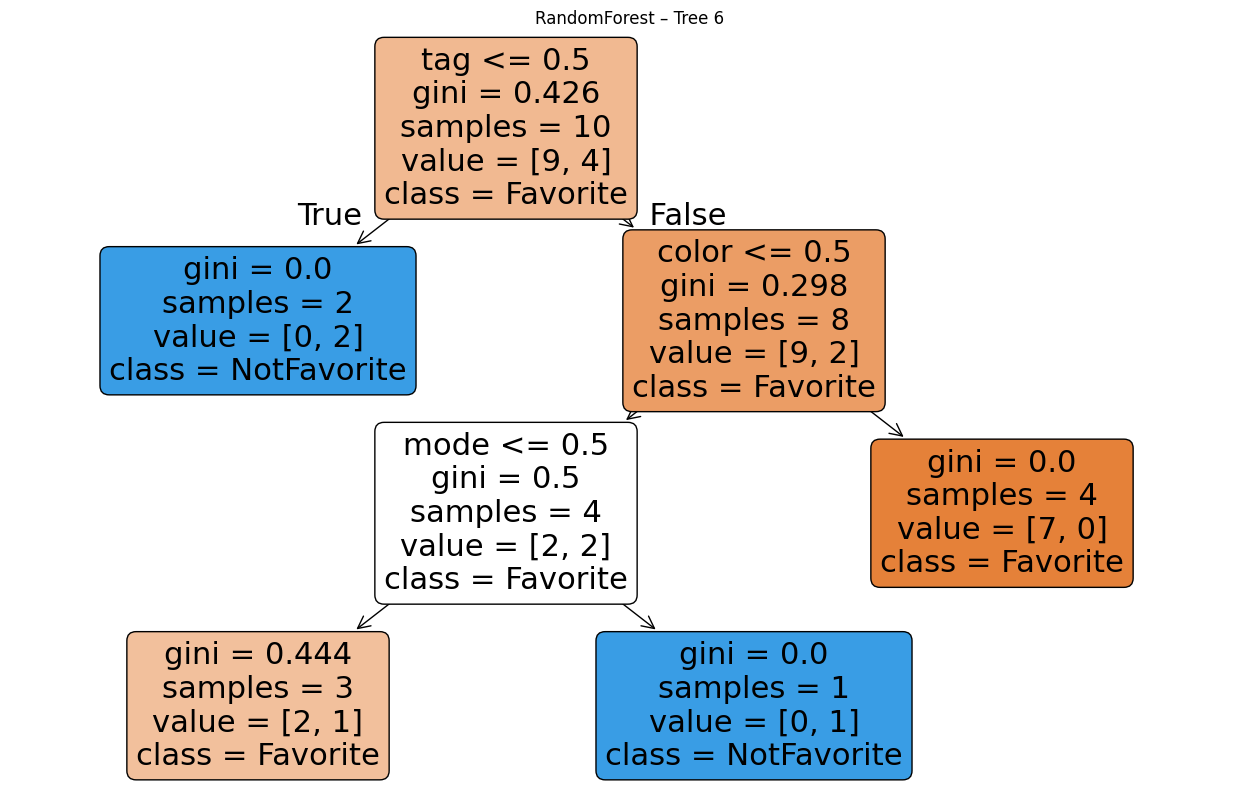

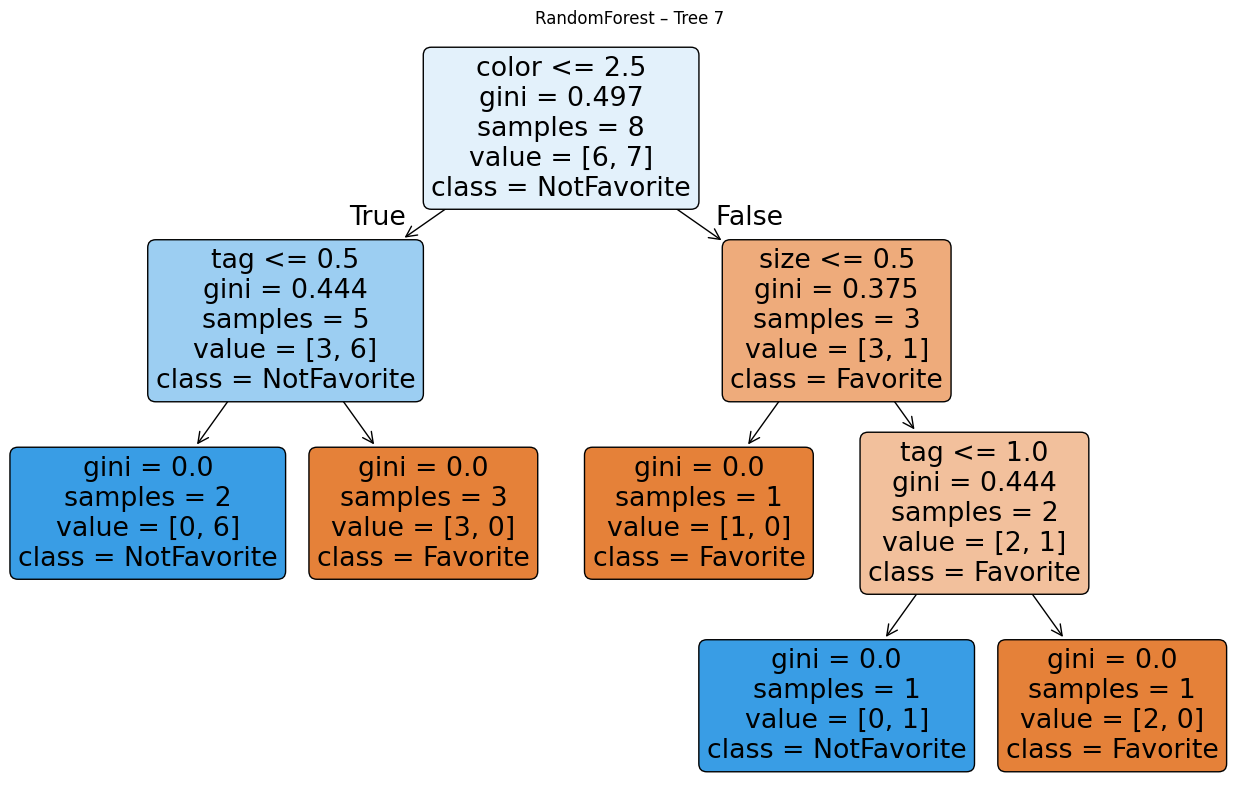

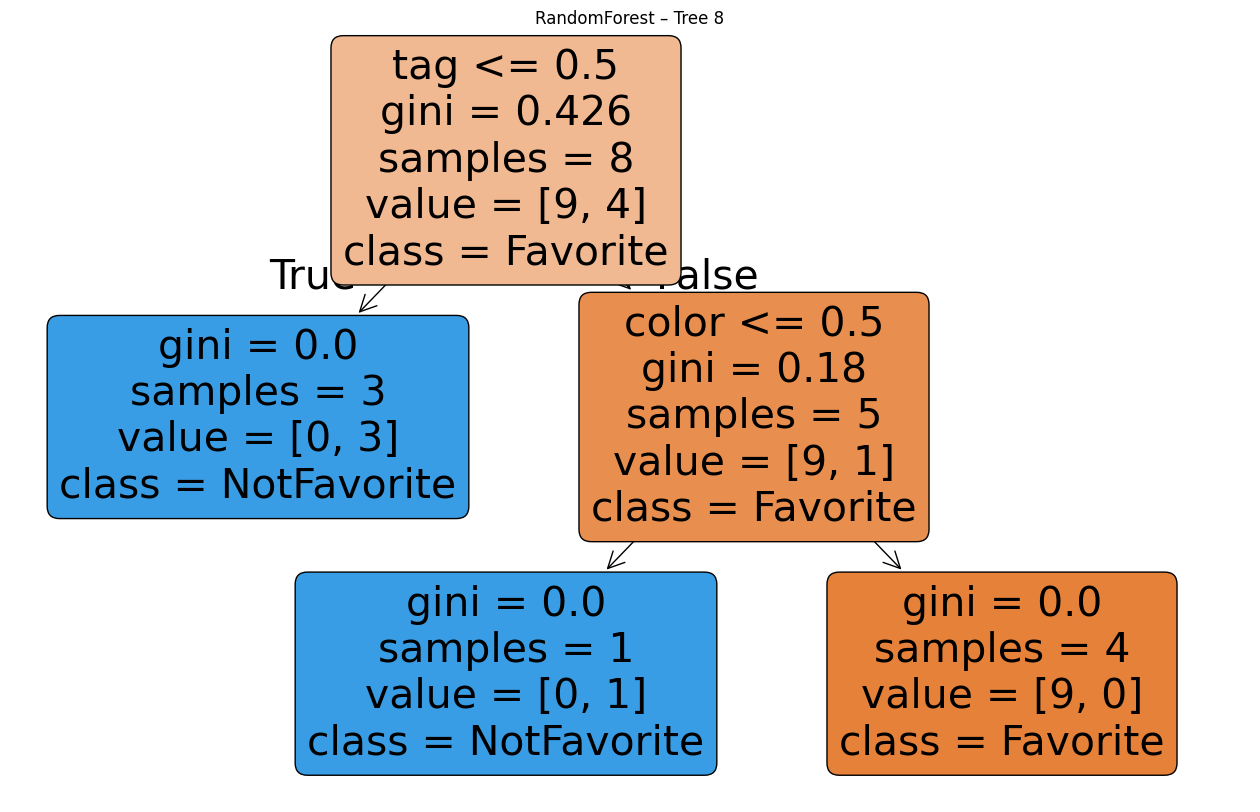

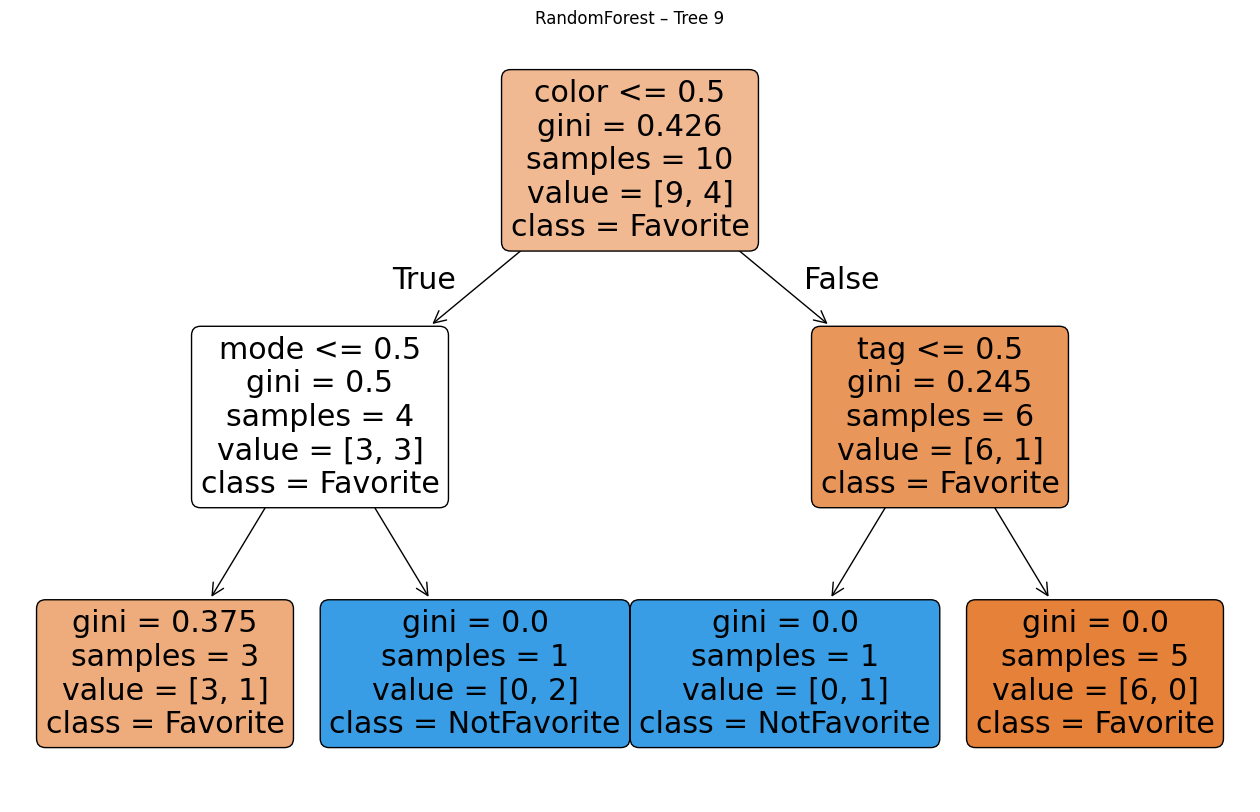

In [29]:
from sklearn import tree
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from IPython.display import Image, display

data = [
    ["green", "nature", "thumbnail", "landscape"],
    ["blue", "architecture", "medium", "portrait"],
    ["blue", "people", "medium", "landscape"],
    ["yellow", "nature", "medium", "portrait"],
    ["green", "nature", "thumbnail", "landscape"],
    ["blue", "people", "medium", "landscape"],
    ["blue", "nature", "thumbnail", "portrait"],
    ["yellow", "architecture", "thumbnail", "landscape"],
    ["blue", "people", "medium", "portrait"],
    ["yellow", "nature", "medium", "landscape"],
    ["yellow", "people", "thumbnail", "portrait"],
    ["blue", "people", "medium", "landscape"],
    ["red", "architecture", "thumbnail", "landscape"],
]
result = [
    "Favorite",
    "NotFavorite",
    "Favorite",
    "Favorite",
    "Favorite",
    "Favorite",
    "Favorite",
    "NotFavorite",
    "NotFavorite",
    "Favorite",
    "Favorite",
    "NotFavorite",
    "NotFavorite",
]


# creating dataframes
dataframe = pd.DataFrame(data, columns=["color", "tag", "size", "mode"])
resultframe = pd.DataFrame(result, columns=["favorite"])

# generating numerical labels
le1 = LabelEncoder()
dataframe["color"] = le1.fit_transform(dataframe["color"])

le2 = LabelEncoder()
dataframe["tag"] = le2.fit_transform(dataframe["tag"])

le3 = LabelEncoder()
dataframe["size"] = le3.fit_transform(dataframe["size"])

le4 = LabelEncoder()
dataframe["mode"] = le4.fit_transform(dataframe["mode"])

le5 = LabelEncoder()
resultframe["favorite"] = le5.fit_transform(resultframe["favorite"])

# Use of decision tree classifiers
rfc = RandomForestClassifier(
    n_estimators=10,
    max_depth=3,
    random_state=0,
)

rfc = rfc.fit(dataframe.values, resultframe.values.ravel())

class_names = le5.inverse_transform(rfc.classes_)

for i in range(10):
    plt.figure(figsize=(16, 10))
    tree.plot_tree(
        rfc.estimators_[i],
        feature_names=dataframe.columns,
        class_names=class_names,
        filled=True,
        rounded=True,
        max_depth=3   # strongly recommended for RF trees
    )
    plt.title(f"RandomForest – Tree {i}")
    plt.show()

**Question 1 : Comparaison entre arbre de décision et forêt aléatoire**

1. **Comparaison avec un arbre de décision unique** :  
   Comparez les performances de la forêt aléatoire avec un arbre de décision unique (profondeur 2). Quel modèle généralise le mieux sur les données d'entraînement ?  

2. **Effet du nombre d'estimateurs** :  
   Expérimentez avec différents nombres d'arbres dans la forêt (`n_estimators`). Quel impact cela a-t-il sur les prédictions du modèle et l'importance des caractéristiques ?

**Question 2 : Ajustement systématique des hyperparamètres**

Créez une comparaison systématique des performances de l'arbre de décision avec différentes valeurs de `max_depth` :

1. Entraînez des arbres de décision avec les valeurs de `max_depth` : 2, 4, 6, 8, 10, None (illimité)
2. Pour chacun, enregistrez la précision d'entraînement et un simple "test" sur des échantillons réservés
3. Créez un tableau récapitulatif :

| max_depth | Précision entraînement | Caractéristique la plus importante |
|-----------|------------------------|-------------------------------------|
| 2 | ? | ? |
| 4 | ? | ? |
| 6 | ? | ? |
| 8 | ? | ? |
| 10 | ? | ? |
| None | ? | ? |

4. Questions à répondre :
   - À quelle profondeur l'arbre commence-t-il à sur-ajuster ?
   - Comment l'importance des caractéristiques change-t-elle avec la profondeur de l'arbre ?
   - Quel est le compromis entre profondeur de l'arbre et interprétabilité ?

```python
max_depths = [2, 4, 6, 8, 10, None]
results = []

for depth in max_depths:
    dtc = tree.DecisionTreeClassifier(max_depth=depth)
    dtc.fit(dataframe.values, resultframe)
    train_accuracy = dtc.score(dataframe.values, resultframe)
    importance = dtc.feature_importances_
    results.append({
        'depth': depth,
        'accuracy': train_accuracy,
        'top_feature': dataframe.columns[importance.argmax()]
    })
```

## Exercice 4 \[★★\]



Nous avons maintenant divisé nos données MNIST (écriture) en deux : les données de formation et les données de test pour la création de modèles de prédiction et nous avons introduit les données de formation complètes dans notre classificateur. Cependant, dans la vie réelle, nous pouvons avoir de nouvelles données à former. Vérifiez le code suivant à l'aide du perceptron et comparez-le avec le code de l'exercice 3

In [30]:
from sklearn import datasets, metrics
from sklearn.linear_model import Perceptron
import numpy as np
import matplotlib.pyplot as plot

digits = datasets.load_digits()
training_size = int(digits.images.shape[0] / 2)

training_images = digits.images[0:training_size]
training_images = training_images.reshape((training_images.shape[0], -1))

training_target = digits.target[0:training_size]

classifier = Perceptron(max_iter=1000)
# training
for i in range(training_size):
    training_data = np.array(training_images[i])
    training_data = training_data.reshape(1, -1)
    classifier.partial_fit(
        training_data, [training_target[i]], classes=np.unique(digits.target)
    )

# prediction
predict_images = digits.images[training_size + 1 :]
actual_labels = digits.target[training_size + 1 :]
predicted_labels = classifier.predict(
    predict_images.reshape((predict_images.shape[0], -1))
)

# classification report
print(metrics.classification_report(actual_labels, predicted_labels))

              precision    recall  f1-score   support

           0       0.98      0.92      0.95        88
           1       1.00      0.44      0.61        91
           2       0.77      1.00      0.87        86
           3       0.95      0.77      0.85        91
           4       0.78      0.90      0.83        92
           5       0.75      0.92      0.83        91
           6       0.89      0.99      0.94        91
           7       1.00      0.88      0.93        89
           8       0.80      0.80      0.80        87
           9       0.79      0.89      0.84        92

    accuracy                           0.85       898
   macro avg       0.87      0.85      0.84       898
weighted avg       0.87      0.85      0.84       898



Cette approche est appelée [online machine training](https://en.wikipedia.org/wiki/Online_machine_learning) (ou
[algorithme d'apprentissage incrémental
(fr)](https://fr.wikipedia.org/wiki/Algorithme_d%27apprentissage_incr%C3%A9mental)).
Avez-vous obtenu une bonne précision ?

**Question 1 : Apprentissage en ligne avec MLPClassifier**

Modifiez le programme ci-dessus pour tester l'apprentissage en ligne avec `MLPClassifier`.

```python
from sklearn.neural_network import MLPClassifier
classifier = MLPClassifier(hidden_layer_sizes=(50,), max_iter=1)
```

**Tâches :**
1. Implémentez `partial_fit()` pour MLPClassifier (similaire au Perceptron)
2. Variez la taille des données d'entraînement (25%, 50%, 75% du dataset)
3. Enregistrez la précision pour chaque configuration

**Questions à répondre :**
- Comment la taille d'entraînement affecte-t-elle la précision ?
- Comparez la précision de l'apprentissage en ligne vs l'apprentissage par lot (utilisant `fit()`)
- Quels sont les compromis entre l'apprentissage en ligne et par lot ?

**Question 2 : Effet des couches cachées**

En utilisant l'apprentissage en ligne avec MLPClassifier :
1. Essayez différents `hidden_layer_sizes` : (25,), (50,), (100,), (50, 50)
2. Enregistrez la précision et le temps d'entraînement pour chaque configuration

Créez un tableau récapitulatif :

| Couches cachées | Précision | Temps d'entraînement |
|-----------------|-----------|----------------------|
| (25,) | ? | ? |
| (50,) | ? | ? |
| (100,) | ? | ? |
| (50, 50) | ? | ? |

**Question 3 : Persistance des modèles - Sauvegarder et charger des modèles**

Après avoir entraîné votre meilleur classificateur, sauvegardez-le pour une utilisation future :

```python
import joblib

# Entraîner votre meilleur modèle
classifier = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000)
classifier.fit(training_images, training_target)

# Sauvegarder le modèle
joblib.dump(classifier, 'digit_classifier.pkl')
print("Modèle sauvegardé !")

# Plus tard, charger le modèle
loaded_classifier = joblib.load('digit_classifier.pkl')

# Vérifier qu'il fonctionne
predictions = loaded_classifier.predict(test_images)
print("Modèle chargé et fonctionnel !")
```

**Tâches :**
1. Entraînez un MLPClassifier sur les données MNIST
2. Sauvegardez le modèle en utilisant joblib
3. Chargez le modèle dans une nouvelle cellule
4. Vérifiez que le modèle chargé produit les mêmes prédictions
5. Quelle est la taille du fichier du modèle sauvegardé ? Comment varie-t-elle selon les architectures ?

**Idée clé** : L'apprentissage en ligne est utile quand :
- Les données arrivent en flux (applications temps réel)
- Le dataset est trop grand pour tenir en mémoire
- Le modèle doit s'adapter à des motifs changeants au fil du temps

La persistance des modèles est essentielle quand :
- L'entraînement prend beaucoup de temps et vous ne voulez pas réentraîner
- Déployer des modèles en production
- Partager des modèles avec d'autres

## Résumé

Félicitations pour avoir terminé le TP 3 ! Voici un récapitulatif de ce que vous avez appris :

### Points clés à retenir

**1. Régression**
- **Régression linéaire** : Ajuste une droite aux données ; fonctionne bien pour les relations linéaires
- **Régression polynomiale** : Utilise des caractéristiques polynomiales pour capturer les motifs non linéaires
- **Compromis** : Des polynômes de degré élevé peuvent sur-ajuster ; des degrés bas peuvent sous-ajuster

**2. Algorithmes de classification**

| Algorithme | Forces | Faiblesses |
|------------|--------|------------|
| Perceptron | Simple, rapide, apprentissage en ligne | Limité aux données linéairement séparables |
| SVM | Efficace en haute dimension | Plus lent sur les grands datasets |
| MLPClassifier | Peut apprendre des motifs complexes | Nécessite ajustement, plus de données |

**3. Arbres de décision et forêts aléatoires**
- Les arbres de décision sont interprétables mais sujets au sur-ajustement
- Les forêts aléatoires combinent plusieurs arbres pour une meilleure généralisation
- L'importance des caractéristiques aide à comprendre ce qui guide les prédictions

**4. Apprentissage en ligne**
- `partial_fit()` permet un entraînement incrémental
- Utile pour les données en flux ou les contraintes de mémoire
- Peut sacrifier un peu de précision par rapport à l'apprentissage par lot

### Et après ?

- Expérimentez avec différents hyperparamètres
- Essayez ces algorithmes sur vos propres datasets
- Explorez la validation croisée pour une évaluation plus robuste
- Considérez les méthodes d'ensemble pour améliorer les performances